# CoTracker vs DINO Tracking: Comprehensive Comparison

This notebook compares the matter-weighted tracking metrics between:
- **CoTracker Baseline**: Random point initialization with standard tracking
- **DINO Tracking**: HDGMM with DINO features

Metrics compared:
- Recall (object matter staying in mask)
- Precision (predicted matter correctness)
- F1 (harmonic mean)

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Set style
plt.style.use('default')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

In [10]:
# Load and analyze all_videos_summary.json
summary_path = '/home/esli/GenParticles_NeurIPS/cotracker_baseline/cotracker_TAPVID_even_init/all_videos_summary.json'
with open(summary_path, 'r') as f:
    summary_data = json.load(f)

print("=== CoTracker TAPVID Experiment 1 Results ===")
print("\nMean Jaccard per video:")
print("-" * 40)

# Extract video names and their mean jaccard scores
for video_name, video_data in summary_data.items():
    if isinstance(video_data, dict) and 'mean_jaccard' in video_data:
        mean_jaccard = video_data['mean_jaccard']
        print(f"{video_name:20s}: {mean_jaccard:.4f}")

# Calculate overall mean jaccard across all videos
all_mean_jaccards = []
for video_name, video_data in summary_data.items():
    if isinstance(video_data, dict) and 'mean_jaccard' in video_data:
        all_mean_jaccards.append(video_data['mean_jaccard'])

overall_mean_jaccard = np.mean(all_mean_jaccards)
print("-" * 40)
print(f"{'Overall Mean Jaccard':20s}: {overall_mean_jaccard:.4f}")
print(f"Number of videos: {len(all_mean_jaccards)}")



=== CoTracker TAPVID Experiment 1 Results ===

Mean Jaccard per video:
----------------------------------------
drift-chicane       : 0.6340
bike-packing        : 0.7523
blackswan           : 0.9932
bmx-trees           : 0.8122
breakdance          : 0.1108
camel               : 0.9757
car-roundabout      : 0.9946
car-shadow          : 0.9612
cows                : 0.9608
dance-twirl         : 0.4898
dog                 : 0.5571
dogs-jump           : 0.8474
drift-straight      : 0.6017
goat                : 0.9603
gold-fish           : 0.9684
horsejump-high      : 0.9246
india               : 0.9775
judo                : 0.8913
kite-surf           : 0.9155
lab-coat            : 0.8947
libby               : 0.7942
loading             : 0.9888
mbike-trick         : 0.9261
motocross-jump      : 0.4074
paragliding-launch  : 0.5430
parkour             : 0.1377
pigs                : 0.9681
scooter-black       : 0.9698
shooting            : 0.9963
soapbox             : 0.4650
------------------

In [10]:
# Load and analyze TAPVID experiment results
# tapvid_path = '/home/esli/GenParticles_NeurIPS/TAPVID_subsampling_exp1/subsample_100_0/all_videos_experiment_results.json'

tapvid_path = '/home/esli/GenParticles_NeurIPS/TAPVID_exp5/all_videos_experiment_results.json'

with open(tapvid_path, 'r') as f:
    tapvid_data = json.load(f)

print("\n=== TAPVID Experiment 1 Results ===")
print("\nJaccard scores per video for each metric type:")
print("-" * 88)

# Initialize lists to collect all jaccard scores for each metric type
particle_jaccards = []
unweighted_jaccards = []
matter_adaptive_jaccards = []
matter_fixed_jaccards = []

# Print header
print(f"{'Video':<20} {'Particle':<12} {'Unweighted':<12} {'Matter Adapt':<12} {'Matter Fixed':<12} {'Obj Particles':<12}")
print("-" * 88)

# Extract jaccard scores for each video
for video_name, video_data in tapvid_data.items():
    if isinstance(video_data, dict):
        # Extract the 4 different jaccard metrics
        particle_jaccard = video_data.get('particle_jaccard', 0)
        unweighted_jaccard = video_data.get('particle_count_unweighted_jaccard', 0)
        matter_adaptive_jaccard = video_data.get('particle_count_matter_adaptive_jaccard', 0)
        matter_fixed_jaccard = video_data.get('particle_count_matter_fixed_jaccard', 0)
        
        # Extract number of object particles
        n_object_particles = video_data.get('n_object_particles', 0)
        
        # Add to lists for overall mean calculation
        particle_jaccards.append(particle_jaccard)
        unweighted_jaccards.append(unweighted_jaccard)
        matter_adaptive_jaccards.append(matter_adaptive_jaccard)
        matter_fixed_jaccards.append(matter_fixed_jaccard)
        
        # Print video results
        print(f"{video_name:<20} {particle_jaccard:<12.4f} {unweighted_jaccard:<12.4f} {matter_adaptive_jaccard:<12.4f} {matter_fixed_jaccard:<12.4f} {n_object_particles:<12}")

# Calculate and print overall means
print("-" * 88)
print(f"{'OVERALL MEANS':<20} {np.mean(particle_jaccards):<12.4f} {np.mean(unweighted_jaccards):<12.4f} {np.mean(matter_adaptive_jaccards):<12.4f} {np.mean(matter_fixed_jaccards):<12.4f} {'N/A':<12}")
print(f"Number of videos: {len(particle_jaccards)}")

print("\n=== Summary of Mean Jaccard Scores (Mean over all videos, after computing the mean over all frames per video) ===")
print(f"2D Projected Particle Means:        {np.mean(particle_jaccards):.4f}")
print(f"Particle-Assignment in GT Segmask Pixels (Unweighted --> Each particle has weight 1):  {np.mean(unweighted_jaccards):.4f}")
print(f"Particle-Assignment in GT Segmask Pixels (Matter Adaptive):     {np.mean(matter_adaptive_jaccards):.4f}")
print(f"Particle-Assignment in GT Segmask Pixels (Matter Fixed):        {np.mean(matter_fixed_jaccards):.4f}")



=== TAPVID Experiment 1 Results ===

Jaccard scores per video for each metric type:
----------------------------------------------------------------------------------------
Video                Particle     Unweighted   Matter Adapt Matter Fixed Obj Particles
----------------------------------------------------------------------------------------
blackswan            0.8281       0.6999       0.9246       0.8994       45          
bike-packing         0.4972       0.6223       0.7150       0.6940       23          
bmx-trees            0.3786       0.2123       0.4501       0.4054       10          
breakdance           0.3495       0.5097       0.5891       0.5888       17          
camel                0.7960       0.7765       0.9131       0.9332       70          
car-roundabout       0.8332       0.7869       0.8000       0.8439       62          
car-shadow           0.8026       0.7559       0.8154       0.8800       45          
cows                 0.8296       0.6513       0

In [7]:
# Load CoTracker results for comparison
cotracker_summary_path = '/home/esli/GenParticles_NeurIPS/cotracker_baseline/cotracker_TAPVID_exp1/all_videos_summary.json'
with open(cotracker_summary_path, 'r') as f:
    cotracker_summary = json.load(f)

print("\n=== CoTracker vs DINO Tracking Performance Analysis ===")
print("\nComparing CoTracker mean_jaccard with DINO Tracking jaccard metrics:")
print("-" * 112)

# Initialize lists for analysis
performance_gaps = []
video_analysis = []

# Print header
print(f"{'Video':<20} {'CoTracker':<12} {'Particle':<12} {'Unweighted':<12} {'Matter Adapt':<12} {'Matter Fixed':<12} {'Best DINO':<12} {'Gap':<12} {'Obj Particles':<12}")
print("-" * 112)

# Find common videos between CoTracker and DINO results
common_videos = set(cotracker_summary.keys()) & set(tapvid_data.keys())

for video_name in sorted(common_videos):
    if isinstance(cotracker_summary[video_name], dict) and isinstance(tapvid_data[video_name], dict):
        # Get CoTracker jaccard
        cotracker_jaccard = cotracker_summary[video_name].get('mean_jaccard', 0)
        
        # Get DINO jaccard metrics
        particle_jaccard = tapvid_data[video_name].get('particle_jaccard', 0)
        unweighted_jaccard = tapvid_data[video_name].get('particle_count_unweighted_jaccard', 0)
        matter_adaptive_jaccard = tapvid_data[video_name].get('particle_count_matter_adaptive_jaccard', 0)
        matter_fixed_jaccard = tapvid_data[video_name].get('particle_count_matter_fixed_jaccard', 0)
        
        # Get number of object particles
        n_object_particles = tapvid_data[video_name].get('n_object_particles', 0)
        
        # Find best DINO performance
        dino_jaccards = [particle_jaccard, unweighted_jaccard, matter_adaptive_jaccard, matter_fixed_jaccard]
        best_dino_jaccard = max(dino_jaccards)
        
        # Calculate performance gap (positive means CoTracker is better)
        performance_gap = cotracker_jaccard - best_dino_jaccard
        
        # Store for analysis
        video_analysis.append({
            'video': video_name,
            'cotracker_jaccard': cotracker_jaccard,
            'particle_jaccard': particle_jaccard,
            'unweighted_jaccard': unweighted_jaccard,
            'matter_adaptive_jaccard': matter_adaptive_jaccard,
            'matter_fixed_jaccard': matter_fixed_jaccard,
            'best_dino_jaccard': best_dino_jaccard,
            'performance_gap': performance_gap,
            'n_object_particles': n_object_particles
        })
        
        performance_gaps.append(performance_gap)
        
        # Print video results
        print(f"{video_name:<20} {cotracker_jaccard:<12.4f} {particle_jaccard:<12.4f} {unweighted_jaccard:<12.4f} {matter_adaptive_jaccard:<12.4f} {matter_fixed_jaccard:<12.4f} {best_dino_jaccard:<12.4f} {performance_gap:<12.4f} {n_object_particles:<12}")

print("-" * 112)

# Sort videos by performance gap (largest gaps first)
video_analysis.sort(key=lambda x: x['performance_gap'], reverse=True)

print(f"\n=== Videos Where CoTracker Significantly Outperforms DINO Tracking ===")
print("(Sorted by performance gap, largest first)")
print("-" * 92)

# Define threshold for "significant" difference
SIGNIFICANT_THRESHOLD = 0.1  # 5% jaccard difference

significant_gaps = [v for v in video_analysis if v['performance_gap'] > SIGNIFICANT_THRESHOLD]

if significant_gaps:
    print(f"{'Video':<20} {'CoTracker':<12} {'Best DINO':<12} {'Gap':<12} {'Worst DINO Metric':<20} {'Obj Particles':<12}")
    print("-" * 92)
    
    for video_data in significant_gaps:
        # Find which DINO metric performed worst
        dino_metrics = {
            'particle': video_data['particle_jaccard'],
            'unweighted': video_data['unweighted_jaccard'],
            'matter_adaptive': video_data['matter_adaptive_jaccard'],
            'matter_fixed': video_data['matter_fixed_jaccard']
        }
        worst_metric = min(dino_metrics, key=dino_metrics.get)
        
        print(f"{video_data['video']:<20} {video_data['cotracker_jaccard']:<12.4f} {video_data['best_dino_jaccard']:<12.4f} {video_data['performance_gap']:<12.4f} {worst_metric:<20} {video_data['n_object_particles']:<12}")
    
    print(f"\nTotal videos with significant gaps (>{SIGNIFICANT_THRESHOLD:.2f}): {len(significant_gaps)}")
    
    # Extract video names for focus
    focus_videos = [v['video'] for v in significant_gaps]
    print(f"\nVideos to focus on for improvement:")
    print(focus_videos)
    
else:
    print("No videos found with significant performance gaps.")

# Overall statistics
print(f"\n=== Overall Performance Statistics ===")
print(f"Mean performance gap: {np.mean(performance_gaps):.4f}")
print(f"Std performance gap: {np.std(performance_gaps):.4f}")
print(f"Videos where CoTracker is better: {sum(1 for gap in performance_gaps if gap > 0)}/{len(performance_gaps)}")
print(f"Videos where DINO is better: {sum(1 for gap in performance_gaps if gap < 0)}/{len(performance_gaps)}")

# Top 5 videos with largest gaps
print(f"\n=== Top 5 Videos with Largest Performance Gaps ===")
for i, video_data in enumerate(video_analysis[:5]):
    print(f"{i+1}. {video_data['video']}: Gap = {video_data['performance_gap']:.4f}, Obj Particles = {video_data['n_object_particles']}")



=== CoTracker vs DINO Tracking Performance Analysis ===

Comparing CoTracker mean_jaccard with DINO Tracking jaccard metrics:
----------------------------------------------------------------------------------------------------------------
Video                CoTracker    Particle     Unweighted   Matter Adapt Matter Fixed Best DINO    Gap          Obj Particles
----------------------------------------------------------------------------------------------------------------
bike-packing         0.6427       0.4906       0.5686       0.7457       0.7667       0.7667       -0.1240      38          
blackswan            0.9697       0.7366       0.6341       0.8871       0.8165       0.8871       0.0827       40          
bmx-trees            0.8181       0.3102       0.1950       0.3766       0.2882       0.3766       0.4415       34          
breakdance           0.0626       0.4704       0.4628       0.7095       0.6457       0.7095       -0.6469      43          
camel                

In [37]:
from ultralytics import SAM
import matplotlib.pyplot as plt
import cv2
import os
import numpy as np
from tqdm import tqdm

# Load a model
model = SAM("sam2.1_l.pt")

# Display model information (optional)
model.info()

# Base paths
rgb_frames_base = "/home/esli/GenMatter/assets/tapvid_davis_30_videos_processed/tapvid_davis_rgb_frames"
output_base = "/home/esli/GenMatter/assets/tapvid_davis_30_videos_processed/tapvid_davis_SAM_frame0"

# Create output directory if it doesn't exist
os.makedirs(output_base, exist_ok=True)

# Get all video folders
video_folders = [f for f in os.listdir(rgb_frames_base) if os.path.isdir(os.path.join(rgb_frames_base, f))]
video_folders.sort()

print(f"Found {len(video_folders)} video folders: {video_folders}")

# Define minimum threshold for segmentation confidence
MIN_THRESHOLD = 0.15

# Process each video folder
for video_name in tqdm(video_folders, desc="Processing videos"):
    print(f"\nProcessing video: {video_name}")
    
    # Path to the first frame (00000.jpg)
    first_frame_path = os.path.join(rgb_frames_base, video_name, "00000.jpg")
    
    # Check if first frame exists
    if not os.path.exists(first_frame_path):
        print(f"  Warning: First frame not found at {first_frame_path}")
        continue
    
    # Run SAM inference on the first frame
    result = model(first_frame_path)
    
    # Get masks tensor (num_segments, H, W)
    masks = result[0].masks.data
    print(f"  Masks shape: {masks.shape}")
    
    # Create a combined segmentation mask with RGB colors
    num_segments = masks.shape[0]
    height, width = masks.shape[1], masks.shape[2]
    combined_mask = np.full((height, width, 3), 255, dtype=np.uint8)  # Initialize with white (255, 255, 255)
    
    # Generate unique RGB colors for each segment
    np.random.seed(42)  # For reproducible colors across videos
    colors = []
    for i in range(num_segments):
        # Generate random RGB color (avoiding white)
        color = np.random.randint(0, 255, 3)
        # Ensure it's not too close to white
        while np.all(color > 200):
            color = np.random.randint(0, 255, 3)
        colors.append(color)
    
    # Create a priority mask to track which segment has highest confidence for each pixel
    priority_mask = np.zeros((height, width), dtype=np.float32)
    
    # Assign each segment a unique RGB color based on maximum confidence above threshold
    for i in range(num_segments):
        mask = masks[i].cpu().numpy()
        # Only assign pixels where this segment has higher confidence than previously assigned segments
        # AND meets the minimum threshold requirement
        valid_pixels = mask > MIN_THRESHOLD
        update_pixels = valid_pixels & (mask > priority_mask)
        combined_mask[update_pixels] = colors[i]
        priority_mask[update_pixels] = mask[update_pixels]
    
    # Save the combined mask as PNG
    output_path = os.path.join(output_base, f"{video_name}_SAM_frame0.png")
    cv2.imwrite(output_path, cv2.cvtColor(combined_mask, cv2.COLOR_RGB2BGR))  # Convert RGB to BGR for cv2
    
    # print(f"  Saved segmentation mask to: {output_path}")
    # print(f"  Number of segments: {num_segments}")

print(f"\nCompleted processing all {len(video_folders)} videos!")


Model summary: 595 layers, 224,446,642 parameters, 224,446,642 gradients
Found 30 video folders: ['bike-packing', 'blackswan', 'bmx-trees', 'breakdance', 'camel', 'car-roundabout', 'car-shadow', 'cows', 'dance-twirl', 'dog', 'dogs-jump', 'drift-chicane', 'drift-straight', 'goat', 'gold-fish', 'horsejump-high', 'india', 'judo', 'kite-surf', 'lab-coat', 'libby', 'loading', 'mbike-trick', 'motocross-jump', 'paragliding-launch', 'parkour', 'pigs', 'scooter-black', 'shooting', 'soapbox']


Processing videos:   0%|          | 0/30 [00:00<?, ?it/s]


Processing video: bike-packing

image 1/1 /home/esli/GenMatter/assets/tapvid_davis_30_videos_processed/tapvid_davis_rgb_frames/bike-packing/00000.jpg: 1024x1024 1 0, 1 1, 1 2, 1 3, 1 4, 1 5, 1 6, 1 7, 1 8, 1 9, 1 10, 1 11, 1 12, 1 13, 1 14, 1 15, 1 16, 1 17, 1 18, 1 19, 1 20, 1 21, 1 22, 1 23, 1 24, 1 25, 1 26, 1 27, 1 28, 1 29, 1 30, 7500.7ms
Speed: 7.5ms preprocess, 7500.7ms inference, 12.4ms postprocess per image at shape (1, 3, 1024, 1024)
  Masks shape: torch.Size([31, 2026, 3840])


Processing videos:   3%|▎         | 1/30 [00:08<04:18,  8.91s/it]


Processing video: blackswan

image 1/1 /home/esli/GenMatter/assets/tapvid_davis_30_videos_processed/tapvid_davis_rgb_frames/blackswan/00000.jpg: 1024x1024 1 0, 1 1, 1 2, 1 3, 1 4, 1 5, 1 6, 1 7, 1 8, 1 9, 1 10, 1 11, 7655.6ms
Speed: 6.6ms preprocess, 7655.6ms inference, 1.6ms postprocess per image at shape (1, 3, 1024, 1024)


...


Processing video: shooting

image 1/1 /home/esli/GenMatter/assets/tapvid_davis_30_videos_processed/tapvid_davis_rgb_frames/shooting/00000.jpg: 1024x1024 1 0, 1 1, 1 2, 1 3, 1 4, 7406.8ms
Speed: 6.0ms preprocess, 7406.8ms inference, 0.5ms postprocess per image at shape (1, 3, 1024, 1024)


Processing videos:  97%|█████████▋| 29/30 [03:47<00:07,  7.65s/it]

  Masks shape: torch.Size([5, 800, 1920])

Processing video: soapbox

image 1/1 /home/esli/GenMatter/assets/tapvid_davis_30_videos_processed/tapvid_davis_rgb_frames/soapbox/00000.jpg: 1024x1024 1 0, 1 1, 1 2, 1 3, 1 4, 1 5, 1 6, 1 7, 1 8, 1 9, 1 10, 1 11, 1 12, 1 13, 1 14, 1 15, 1 16, 1 17, 1 18, 7409.1ms
Speed: 6.5ms preprocess, 7409.1ms inference, 2.5ms postprocess per image at shape (1, 3, 1024, 1024)
  Masks shape: torch.Size([19, 1080, 1920])


Processing videos: 100%|██████████| 30/30 [03:55<00:00,  7.84s/it]


Completed processing all 30 videos!


## 1. Load Results

In [2]:
# Load CoTracker results
cotracker_path = '/home/esli/GenParticles_NeurIPS/cotracker_baseline/full_suite_results/all_videos_summary.json'
with open(cotracker_path, 'r') as f:
    cotracker_results = json.load(f)

# Load DINO Tracking results
dino_path = '/home/esli/GenParticles_NeurIPS/dino_tracking_cvpr_experiment_dino_update/all_videos_experiment_results.json'
with open(dino_path, 'r') as f:
    dino_results = json.load(f)

print(f"CoTracker videos: {len(cotracker_results)}")
print(f"DINO Tracking videos: {len(dino_results)}")

# Find common videos
common_videos = set(cotracker_results.keys()) & set(dino_results.keys())

# Hold out specific videos
HOLDOUT_VIDEOS = {'whiskey_swirl_2', 'wine_swirl', 'purple_jacket'}
common_videos = common_videos - HOLDOUT_VIDEOS

print(f"\nHeld out videos: {sorted(HOLDOUT_VIDEOS)}")
print(f"Common videos (after holdout): {len(common_videos)}")
print(f"Videos: {sorted(common_videos)}")

CoTracker videos: 27
DINO Tracking videos: 27

Held out videos: ['purple_jacket', 'whiskey_swirl_2', 'wine_swirl']
Common videos (after holdout): 24
Videos: ['bear', 'blackswan', 'breakdance', 'breakdance-flare', 'camel', 'cloth_bag', 'cows', 'dance-jump', 'dance-twirl', 'dog', 'elephant', 'flamingo', 'goat', 'gray_jacket', 'hike', 'jello_trim', 'lucia', 'mallard-fly', 'manta_ray', 'new_eagle_trim', 'ostrich_trim', 'parkour', 'rollerblade', 'snake_trim']


## 2. Extract Metrics for Comparison

In [3]:
# Build comparison dataframe
comparison_data = []

for video_name in sorted(common_videos):
    ct = cotracker_results[video_name]
    dino = dino_results[video_name]
    
    # CoTracker metrics
    ct_recall = ct['matter_weighted_recall']
    ct_precision = ct['matter_weighted_precision']
    ct_f1 = ct['matter_weighted_f1']
    
    # DINO metrics (use fixed weights for fair comparison)
    dino_recall = dino['matter_weighted_recall_fixed']
    dino_precision = dino['matter_weighted_precision_fixed']
    dino_f1 = dino['matter_weighted_f1_fixed']
    
    # Compute deltas (positive = DINO better)
    delta_recall = dino_recall - ct_recall
    delta_precision = dino_precision - ct_precision
    delta_f1 = dino_f1 - ct_f1
    
    # Convert FP/FN rates from percentage to fraction
    ct_fn_rate = ct['mean_fn_rate'] / 100.0
    ct_fp_rate = ct['mean_fp_rate'] / 100.0
    dino_fn_rate = dino['mean_fn_rate'] / 100.0
    dino_fp_rate = dino['mean_fp_rate'] / 100.0
    
    # Compute particle-based F1 from FP/FN rates
    # Recall = TP / (TP + FN) = (n_object - FN) / n_object = 1 - FN_rate
    # Precision = TP / (TP + FP) = (n_object - FN) / (n_object - FN + FP)
    def compute_particle_f1(fn_rate, fp_rate, n_object, n_background):
        """Compute F1 score from particle-based FP/FN rates."""
        fn_count = fn_rate * n_object
        fp_count = fp_rate * n_background
        tp_count = n_object - fn_count
        
        recall = 1.0 - fn_rate if n_object > 0 else 0.0
        precision = tp_count / (tp_count + fp_count) if (tp_count + fp_count) > 0 else 0.0
        
        if precision + recall > 0:
            f1 = 2 * (precision * recall) / (precision + recall)
        else:
            f1 = 0.0
        
        return recall, precision, f1
    
    # Get particle counts
    ct_n_object = ct.get('n_object_particles', ct.get('n_object_blobs', 0))
    ct_n_background = ct.get('n_background_particles', ct.get('n_background_blobs', 0))
    dino_n_object = dino.get('n_object_blobs', 0)
    dino_n_background = dino.get('n_background_blobs', 0)
    
    ct_particle_recall, ct_particle_precision, ct_particle_f1 = compute_particle_f1(
        ct_fn_rate, ct_fp_rate, ct_n_object, ct_n_background
    )
    dino_particle_recall, dino_particle_precision, dino_particle_f1 = compute_particle_f1(
        dino_fn_rate, dino_fp_rate, dino_n_object, dino_n_background
    )
    
    # Compute accuracy: (TP + TN) / Total = (correct) / (total)
    # TP = n_object * (1 - FN_rate), TN = n_background * (1 - FP_rate)
    # Total = n_object + n_background
    ct_total = ct_n_object + ct_n_background
    dino_total = dino_n_object + dino_n_background
    
    ct_tp = ct_n_object * (1 - ct_fn_rate) if ct_n_object > 0 else 0
    ct_tn = ct_n_background * (1 - ct_fp_rate) if ct_n_background > 0 else 0
    ct_accuracy = (ct_tp + ct_tn) / ct_total if ct_total > 0 else 0.0
    
    dino_tp = dino_n_object * (1 - dino_fn_rate) if dino_n_object > 0 else 0
    dino_tn = dino_n_background * (1 - dino_fp_rate) if dino_n_background > 0 else 0
    dino_accuracy = (dino_tp + dino_tn) / dino_total if dino_total > 0 else 0.0
    
    delta_accuracy = dino_accuracy - ct_accuracy
    
    comparison_data.append({
        'video': video_name,
        'ct_recall': ct_recall,
        'ct_precision': ct_precision,
        'ct_f1': ct_f1,
        'dino_recall': dino_recall,
        'dino_precision': dino_precision,
        'dino_f1': dino_f1,
        'delta_recall': delta_recall,
        'delta_precision': delta_precision,
        'delta_f1': delta_f1,
        # Particle-based FP/FN rates (as fractions)
        'ct_fn_rate': ct_fn_rate,
        'ct_fp_rate': ct_fp_rate,
        'dino_fn_rate': dino_fn_rate,
        'dino_fp_rate': dino_fp_rate,
        # Particle-based metrics computed from FP/FN
        'ct_particle_recall': ct_particle_recall,
        'ct_particle_precision': ct_particle_precision,
        'ct_particle_f1': ct_particle_f1,
        'dino_particle_recall': dino_particle_recall,
        'dino_particle_precision': dino_particle_precision,
        'dino_particle_f1': dino_particle_f1,
        'delta_particle_f1': dino_particle_f1 - ct_particle_f1,
        # Accuracy: (TP + TN) / Total
        'ct_accuracy': ct_accuracy,
        'dino_accuracy': dino_accuracy,
        'delta_accuracy': delta_accuracy,
    })

df = pd.DataFrame(comparison_data)

# Display full comparison table
print("\n" + "="*100)
print("FULL COMPARISON TABLE")
print("="*100)
print(df[['video', 'ct_recall', 'dino_recall', 'delta_recall', 
          'ct_precision', 'dino_precision', 'delta_precision',
          'ct_f1', 'dino_f1', 'delta_f1']].to_string(index=False))

df.head()


FULL COMPARISON TABLE
           video  ct_recall  dino_recall  delta_recall  ct_precision  dino_precision  delta_precision    ct_f1  dino_f1  delta_f1
            bear   0.941304     0.931315     -0.009989      0.999526        0.977423        -0.022104 0.969542 0.953646 -0.015895
       blackswan   0.977737     0.900723     -0.077014      0.999373        0.995624        -0.003749 0.988437 0.945520 -0.042916
      breakdance   0.712381     0.967877      0.255495      0.999601        0.853263        -0.146338 0.831898 0.904060  0.072162
breakdance-flare   0.849169     0.809278     -0.039892      0.999719        0.943538        -0.056180 0.918315 0.868476 -0.049839
           camel   0.918219     0.630880     -0.287339      0.997945        0.981458        -0.016487 0.956424 0.742291 -0.214132
       cloth_bag   0.998306     0.994669     -0.003637      0.999852        0.930310        -0.069541 0.999078 0.960205 -0.038874
            cows   0.936179     0.915130     -0.021050      0.99838

,video,ct_recall,ct_precision,ct_f1,dino_recall,dino_precision,dino_f1,delta_recall,delta_precision,delta_f1,...,ct_particle_recall,ct_particle_precision,ct_particle_f1,dino_particle_recall,dino_particle_precision,dino_particle_f1,delta_particle_f1,ct_accuracy,dino_accuracy,delta_accuracy
0,bear,0.941304,0.999526,0.969542,0.931315,0.977423,0.953646,-0.009989,-0.022104,-0.015895,...,0.941304,0.996104,0.967929,0.948373,0.873611,0.909458,-0.058471,0.992889,0.980075,-0.012814
1,blackswan,0.977737,0.999373,0.988437,0.900723,0.995624,0.945520,-0.077014,-0.003749,-0.042916,...,0.977737,0.993402,0.985507,0.931122,0.852804,0.890244,-0.095263,0.997469,0.981949,-0.015521
2,breakdance,0.712381,0.999601,0.831898,0.967877,0.853263,0.904060,0.255495,-0.146338,0.072162,...,0.712381,0.994631,0.830172,0.892319,0.669302,0.764886,-0.065286,0.972602,0.954757,-0.017845
3,breakdance-flare,0.849169,0.999719,0.918315,0.809278,0.943538,0.868476,-0.039892,-0.056180,-0.049839,...,0.849169,0.996491,0.916951,0.898901,0.763772,0.825846,-0.091105,0.986771,0.974529,-0.012242
4,camel,0.918219,0.997945,0.956424,0.630880,0.981458,0.742291,-0.287339,-0.016487,-0.214132,...,0.918219,0.988214,0.951932,0.925698,0.858632,0.890904,-0.061027,0.985348,0.964324,-0.021024


## 3. Summary Statistics

In [4]:
print("="*100)
print("AGGREGATE STATISTICS")
print("="*100)

print("\n📊 CoTracker Baseline:")
print(f"  Recall:     {df['ct_recall'].mean():.3f} ± {df['ct_recall'].std():.3f}")
print(f"  Precision:  {df['ct_precision'].mean():.3f} ± {df['ct_precision'].std():.3f}")
print(f"  F1:         {df['ct_f1'].mean():.3f} ± {df['ct_f1'].std():.3f}")

print("\n📊 DINO Tracking (Fixed Weights):")
print(f"  Recall:     {df['dino_recall'].mean():.3f} ± {df['dino_recall'].std():.3f}")
print(f"  Precision:  {df['dino_precision'].mean():.3f} ± {df['dino_precision'].std():.3f}")
print(f"  F1:         {df['dino_f1'].mean():.3f} ± {df['dino_f1'].std():.3f}")

print("\n📈 Improvement (DINO - CoTracker):")
print(f"  Recall:     {df['delta_recall'].mean():+.3f} ± {df['delta_recall'].std():.3f}")
print(f"  Precision:  {df['delta_precision'].mean():+.3f} ± {df['delta_precision'].std():.3f}")
print(f"  F1:         {df['delta_f1'].mean():+.3f} ± {df['delta_f1'].std():.3f}")

print("\n📊 Win/Loss Counts (DINO vs CoTracker):")
print(f"  DINO better F1:     {(df['delta_f1'] > 0).sum()} / {len(df)}")
print(f"  CoTracker better F1: {(df['delta_f1'] < 0).sum()} / {len(df)}")
print(f"  Tied:               {(df['delta_f1'] == 0).sum()} / {len(df)}")

# Determine overall winner
mean_f1_improvement = df['delta_f1'].mean()
print("\n" + "="*100)
print("CONCLUSION")
print("="*100)
if mean_f1_improvement > 0.01:
    print(f"✅ DINO Tracking is BETTER with average F1 improvement of {mean_f1_improvement:+.3f}")
elif mean_f1_improvement < -0.01:
    print(f"✅ CoTracker is BETTER with average F1 improvement of {-mean_f1_improvement:+.3f}")
else:
    print(f"⚖️  Methods are COMPARABLE with negligible difference ({mean_f1_improvement:+.3f})")

AGGREGATE STATISTICS

📊 CoTracker Baseline:
  Recall:     0.899 ± 0.076
  Precision:  0.999 ± 0.001
  F1:         0.945 ± 0.043

📊 DINO Tracking (Fixed Weights):
  Recall:     0.839 ± 0.127
  Precision:  0.942 ± 0.063
  F1:         0.878 ± 0.096

📈 Improvement (DINO - CoTracker):
  Recall:     -0.060 ± 0.130
  Precision:  -0.057 ± 0.063
  F1:         -0.066 ± 0.088

📊 Win/Loss Counts (DINO vs CoTracker):
  DINO better F1:     4 / 24
  CoTracker better F1: 20 / 24
  Tied:               0 / 24

CONCLUSION
✅ CoTracker is BETTER with average F1 improvement of +0.066


## 4. Per-Video Comparison Visualization

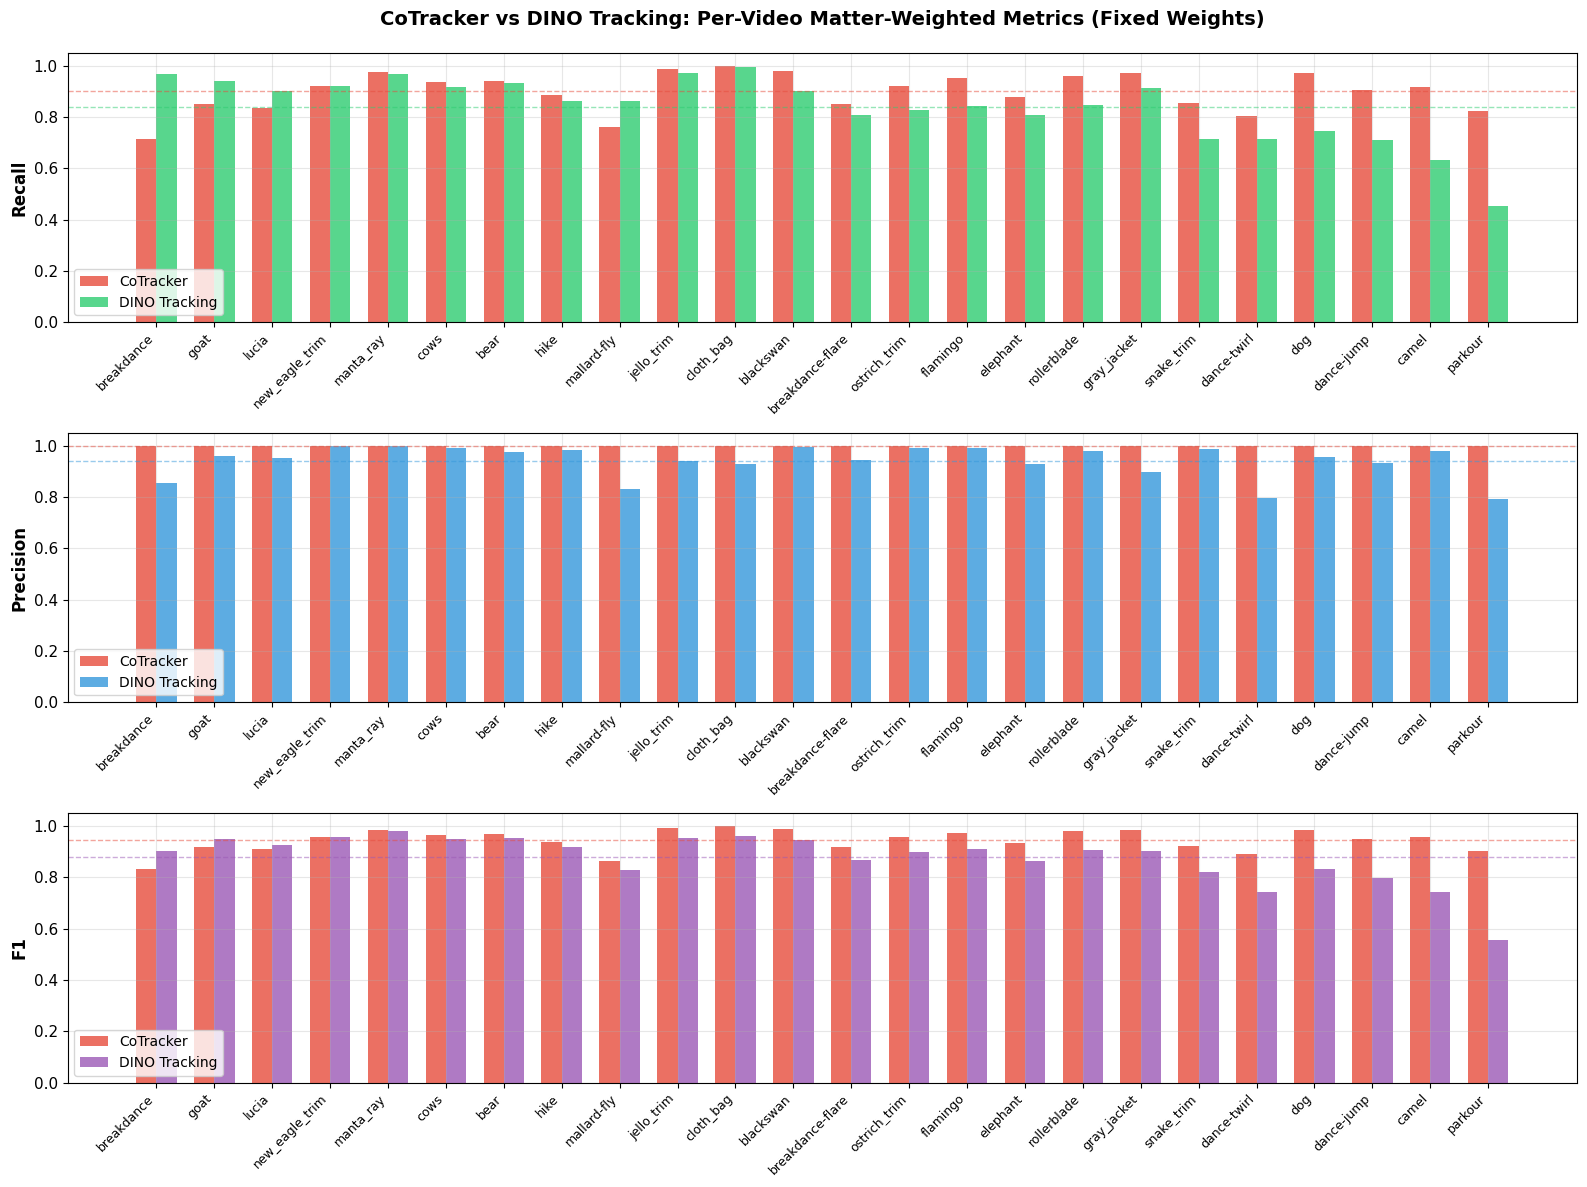

Saved: comparison_per_video_metrics.png


In [5]:
# Sort by F1 delta for better visualization
df_sorted = df.sort_values('delta_f1', ascending=False)

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

metrics = ['recall', 'precision', 'f1']
metric_names = ['Recall', 'Precision', 'F1']
colors = ['#2ecc71', '#3498db', '#9b59b6']

for idx, (metric, name, color) in enumerate(zip(metrics, metric_names, colors)):
    ax = axes[idx]
    
    x = np.arange(len(df_sorted))
    width = 0.35
    
    ct_vals = df_sorted[f'ct_{metric}'].values
    dino_vals = df_sorted[f'dino_{metric}'].values
    
    ax.bar(x - width/2, ct_vals, width, label='CoTracker', alpha=0.8, color='#e74c3c')
    ax.bar(x + width/2, dino_vals, width, label='DINO Tracking', alpha=0.8, color=color)
    
    ax.set_ylabel(name, fontsize=12, fontweight='bold')
    ax.set_ylim([0, 1.05])
    ax.set_xticks(x)
    ax.set_xticklabels(df_sorted['video'].values, rotation=45, ha='right', fontsize=9)
    ax.legend(loc='lower left', fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.axhline(y=df[f'ct_{metric}'].mean(), color='#e74c3c', linestyle='--', 
               linewidth=1, alpha=0.5, label=f'CT Mean: {df[f"ct_{metric}"].mean():.3f}')
    ax.axhline(y=df[f'dino_{metric}'].mean(), color=color, linestyle='--', 
               linewidth=1, alpha=0.5, label=f'DINO Mean: {df[f"dino_{metric}"].mean():.3f}')

axes[0].set_title('CoTracker vs DINO Tracking: Per-Video Matter-Weighted Metrics (Fixed Weights)', 
                  fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('/home/esli/GenParticles_NeurIPS/comparison_per_video_metrics.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print("Saved: comparison_per_video_metrics.png")

## 5. Delta (Improvement) Visualization

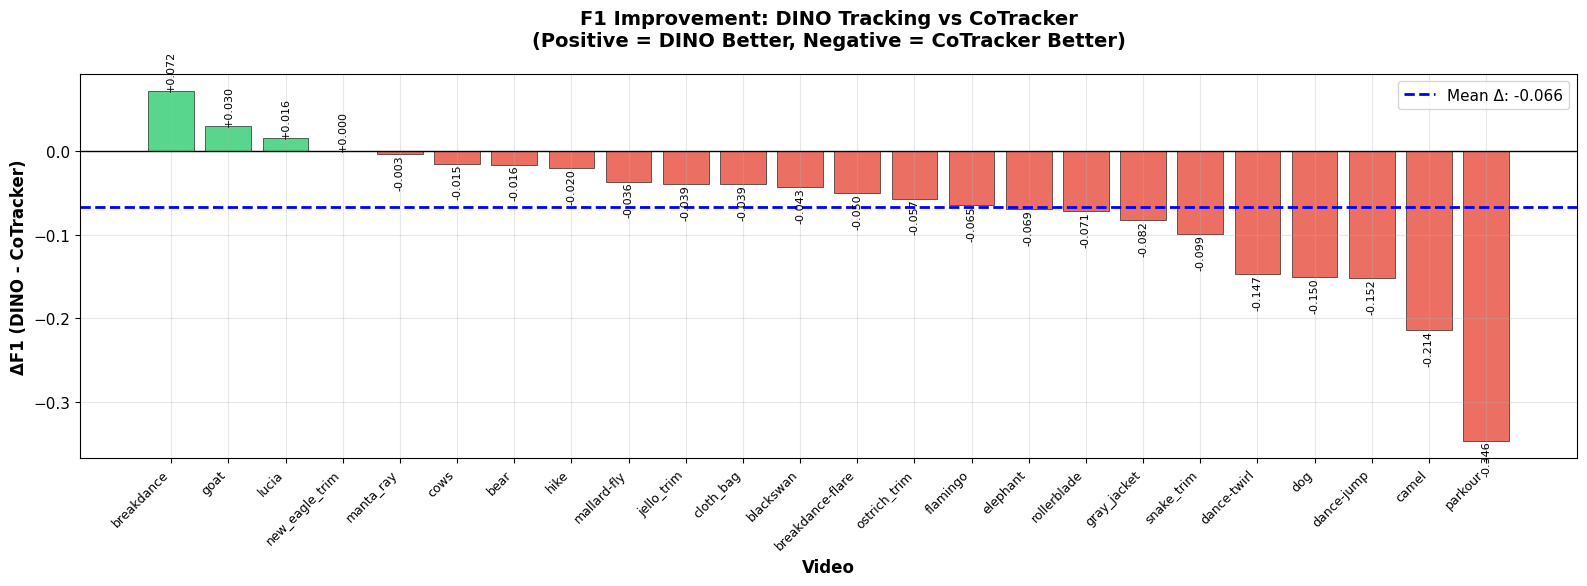

Saved: comparison_f1_delta.png


In [6]:
fig, ax = plt.subplots(figsize=(16, 6))

x = np.arange(len(df_sorted))
deltas = df_sorted['delta_f1'].values

# Color bars based on sign
colors_bar = ['#2ecc71' if d > 0 else '#e74c3c' for d in deltas]

bars = ax.bar(x, deltas, color=colors_bar, alpha=0.8, edgecolor='black', linewidth=0.5)

ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax.axhline(y=df['delta_f1'].mean(), color='blue', linestyle='--', 
           linewidth=2, label=f'Mean Δ: {df["delta_f1"].mean():+.3f}')

ax.set_ylabel('ΔF1 (DINO - CoTracker)', fontsize=12, fontweight='bold')
ax.set_xlabel('Video', fontsize=12, fontweight='bold')
ax.set_title('F1 Improvement: DINO Tracking vs CoTracker\n(Positive = DINO Better, Negative = CoTracker Better)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(df_sorted['video'].values, rotation=45, ha='right', fontsize=9)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (bar, delta) in enumerate(zip(bars, deltas)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{delta:+.3f}',
            ha='center', va='bottom' if height > 0 else 'top', 
            fontsize=8, rotation=90)

plt.tight_layout()
plt.savefig('/home/esli/GenParticles_NeurIPS/comparison_f1_delta.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print("Saved: comparison_f1_delta.png")

## 6. Scatter Plots: Direct Comparison

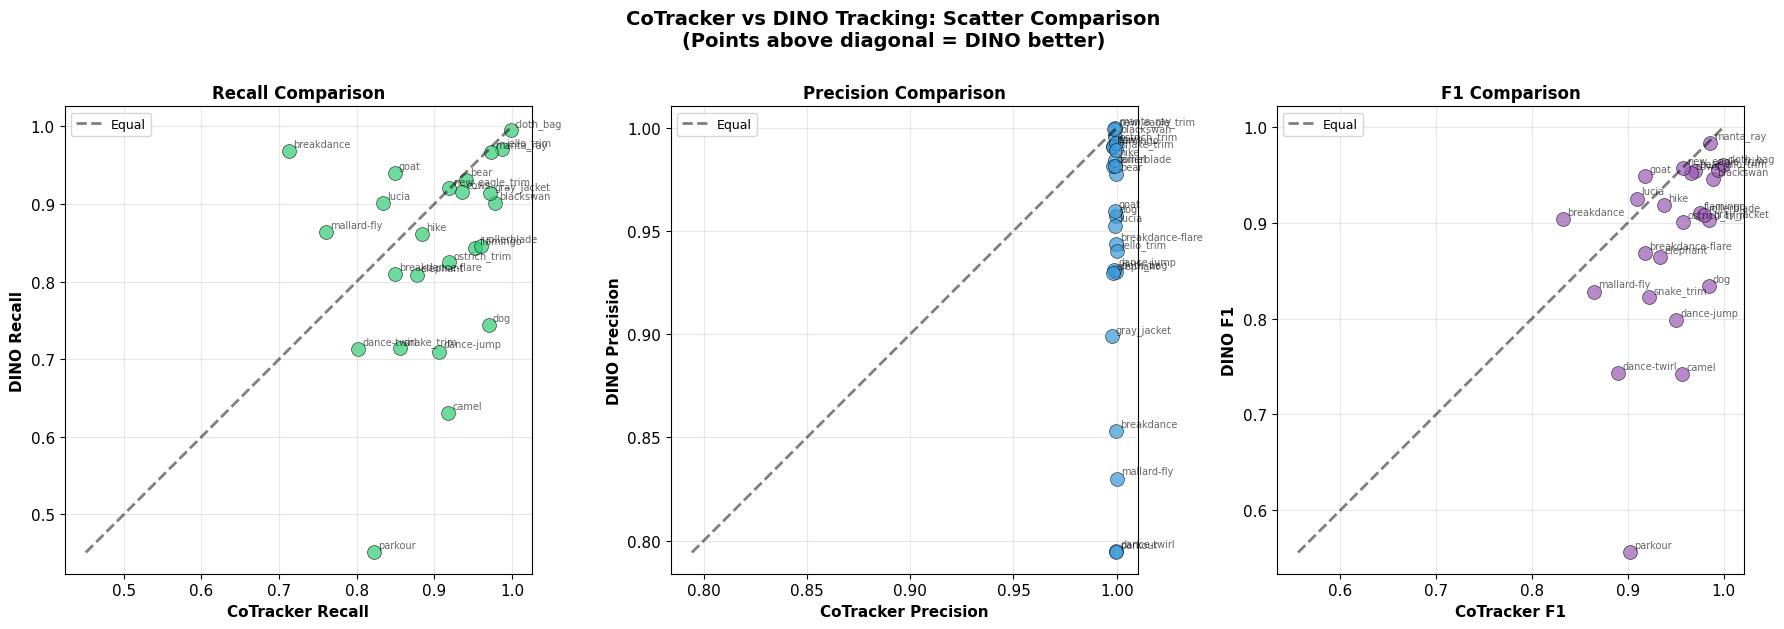

Saved: comparison_scatter.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics = ['recall', 'precision', 'f1']
metric_names = ['Recall', 'Precision', 'F1']
colors = ['#2ecc71', '#3498db', '#9b59b6']

for idx, (metric, name, color) in enumerate(zip(metrics, metric_names, colors)):
    ax = axes[idx]
    
    ct_vals = df[f'ct_{metric}'].values
    dino_vals = df[f'dino_{metric}'].values
    
    ax.scatter(ct_vals, dino_vals, alpha=0.7, s=100, color=color, edgecolor='black', linewidth=0.5)
    
    # Add video labels
    for i, video in enumerate(df['video'].values):
        ax.annotate(video, (ct_vals[i], dino_vals[i]), 
                   fontsize=7, alpha=0.6, xytext=(3, 3), textcoords='offset points')
    
    # Diagonal line (equal performance)
    min_val = min(ct_vals.min(), dino_vals.min())
    max_val = max(ct_vals.max(), dino_vals.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, alpha=0.5, label='Equal')
    
    ax.set_xlabel(f'CoTracker {name}', fontsize=11, fontweight='bold')
    ax.set_ylabel(f'DINO {name}', fontsize=11, fontweight='bold')
    ax.set_title(f'{name} Comparison', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_aspect('equal', adjustable='box')

plt.suptitle('CoTracker vs DINO Tracking: Scatter Comparison\n(Points above diagonal = DINO better)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/home/esli/GenParticles_NeurIPS/comparison_scatter.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print("Saved: comparison_scatter.png")

## 7. Statistical Significance Testing

In [8]:
from scipy import stats

print("="*100)
print("STATISTICAL SIGNIFICANCE TESTS (Paired t-test)")
print("="*100)

for metric, name in zip(['recall', 'precision', 'f1'], ['Recall', 'Precision', 'F1']):
    ct_vals = df[f'ct_{metric}'].values
    dino_vals = df[f'dino_{metric}'].values
    
    # Paired t-test
    t_stat, p_value = stats.ttest_rel(dino_vals, ct_vals)
    
    # Effect size (Cohen's d)
    diff = dino_vals - ct_vals
    cohens_d = diff.mean() / diff.std()
    
    print(f"\n{name}:")
    print(f"  Mean difference (DINO - CoTracker): {diff.mean():+.4f}")
    print(f"  t-statistic: {t_stat:.4f}")
    print(f"  p-value: {p_value:.4f}")
    print(f"  Cohen's d (effect size): {cohens_d:.4f}")
    
    if p_value < 0.001:
        print(f"  ✅ HIGHLY SIGNIFICANT (p < 0.001)")
    elif p_value < 0.01:
        print(f"  ✅ VERY SIGNIFICANT (p < 0.01)")
    elif p_value < 0.05:
        print(f"  ✅ SIGNIFICANT (p < 0.05)")
    else:
        print(f"  ⚠️  NOT SIGNIFICANT (p >= 0.05)")
    
    if abs(cohens_d) >= 0.8:
        print(f"  Effect size: LARGE")
    elif abs(cohens_d) >= 0.5:
        print(f"  Effect size: MEDIUM")
    elif abs(cohens_d) >= 0.2:
        print(f"  Effect size: SMALL")
    else:
        print(f"  Effect size: NEGLIGIBLE")

STATISTICAL SIGNIFICANCE TESTS (Paired t-test)

Recall:
  Mean difference (DINO - CoTracker): -0.0599
  t-statistic: -2.2502
  p-value: 0.0343
  Cohen's d (effect size): -0.4692
  ✅ SIGNIFICANT (p < 0.05)
  Effect size: SMALL

Precision:
  Mean difference (DINO - CoTracker): -0.0575
  t-statistic: -4.4381
  p-value: 0.0002
  Cohen's d (effect size): -0.9254
  ✅ HIGHLY SIGNIFICANT (p < 0.001)
  Effect size: LARGE

F1:
  Mean difference (DINO - CoTracker): -0.0664
  t-statistic: -3.7104
  p-value: 0.0012
  Cohen's d (effect size): -0.7737
  ✅ VERY SIGNIFICANT (p < 0.01)
  Effect size: MEDIUM


## 8. Best/Worst Cases Analysis

In [9]:
print("="*100)
print("TOP 5 VIDEOS WHERE DINO OUTPERFORMS COTRACKER (by F1)")
print("="*100)

top_dino = df.nlargest(5, 'delta_f1')
print(top_dino[['video', 'ct_f1', 'dino_f1', 'delta_f1']].to_string(index=False))

print("\n" + "="*100)
print("TOP 5 VIDEOS WHERE COTRACKER OUTPERFORMS DINO (by F1)")
print("="*100)

top_cotracker = df.nsmallest(5, 'delta_f1')
print(top_cotracker[['video', 'ct_f1', 'dino_f1', 'delta_f1']].to_string(index=False))

print("\n" + "="*100)
print("VIDEOS WITH NEAR-PERFECT PERFORMANCE (F1 > 0.95) - EITHER METHOD")
print("="*100)

high_perf = df[(df['ct_f1'] > 0.95) | (df['dino_f1'] > 0.95)]
if len(high_perf) > 0:
    print(high_perf[['video', 'ct_f1', 'dino_f1']].to_string(index=False))
else:
    print("No videos with F1 > 0.95")

print("\n" + "="*100)
print("CHALLENGING VIDEOS (F1 < 0.80) - EITHER METHOD")
print("="*100)

low_perf = df[(df['ct_f1'] < 0.80) | (df['dino_f1'] < 0.80)]
if len(low_perf) > 0:
    print(low_perf[['video', 'ct_f1', 'dino_f1', 'delta_f1']].to_string(index=False))
else:
    print("No challenging videos (all F1 >= 0.80)")

TOP 5 VIDEOS WHERE DINO OUTPERFORMS COTRACKER (by F1)
         video    ct_f1  dino_f1  delta_f1
    breakdance 0.831898 0.904060  0.072162
          goat 0.917923 0.948369  0.030446
         lucia 0.909034 0.925184  0.016150
new_eagle_trim 0.957181 0.957348  0.000167
     manta_ray 0.986117 0.982631 -0.003486

TOP 5 VIDEOS WHERE COTRACKER OUTPERFORMS DINO (by F1)
      video    ct_f1  dino_f1  delta_f1
    parkour 0.902313 0.555999 -0.346315
      camel 0.956424 0.742291 -0.214132
 dance-jump 0.950270 0.798672 -0.151598
        dog 0.984415 0.833975 -0.150440
dance-twirl 0.889751 0.742929 -0.146821

VIDEOS WITH NEAR-PERFECT PERFORMANCE (F1 > 0.95) - EITHER METHOD
         video    ct_f1  dino_f1
          bear 0.969542 0.953646
     blackswan 0.988437 0.945520
         camel 0.956424 0.742291
     cloth_bag 0.999078 0.960205
          cows 0.966281 0.951522
    dance-jump 0.950270 0.798672
           dog 0.984415 0.833975
      flamingo 0.974969 0.910376
   gray_jacket 0.984654 0.9026

## 9. Box Plot Comparison

/var/tmp/ipykernel_710684/3073420110.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['CoTracker', 'DINO Tracking'],
/var/tmp/ipykernel_710684/3073420110.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['CoTracker', 'DINO Tracking'],
/var/tmp/ipykernel_710684/3073420110.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['CoTracker', 'DINO Tracking'],


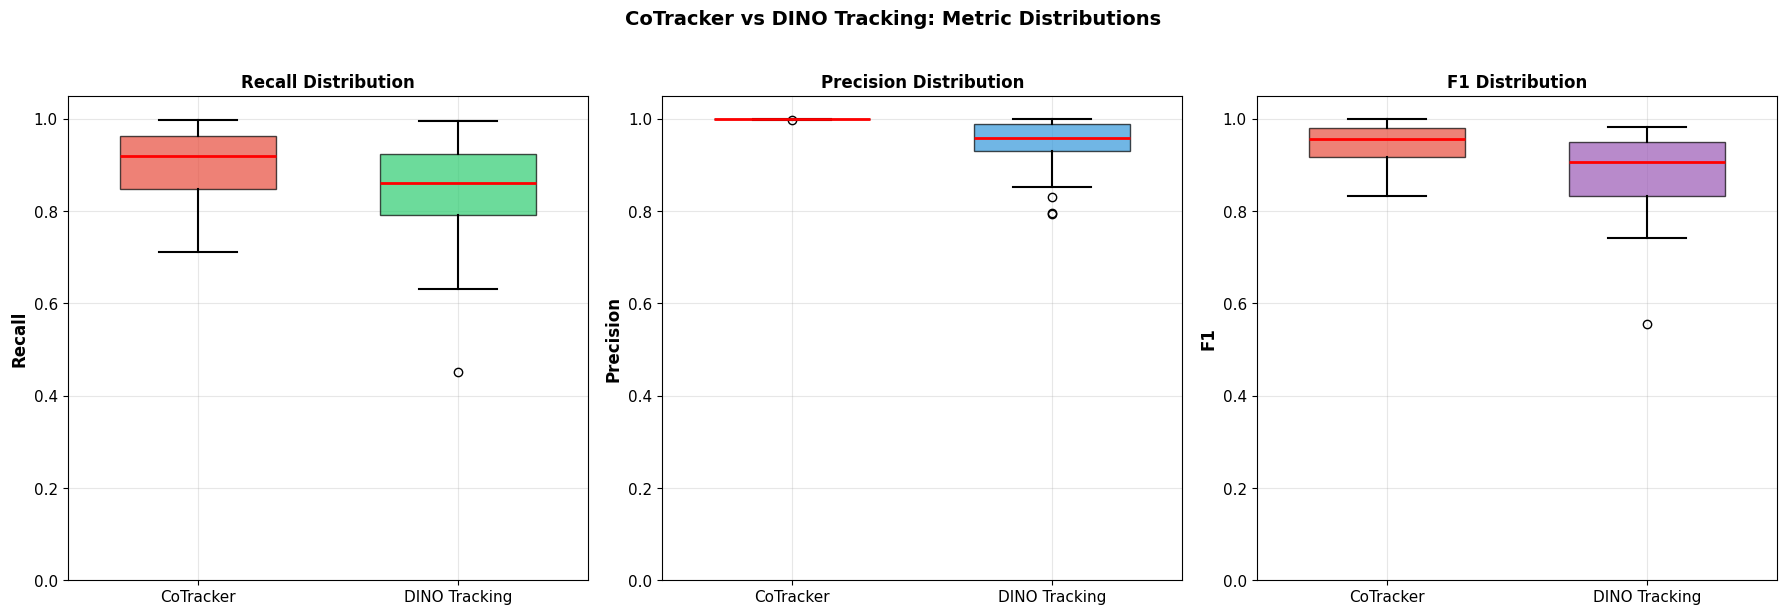

Saved: comparison_boxplot.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics = ['recall', 'precision', 'f1']
metric_names = ['Recall', 'Precision', 'F1']
colors = ['#2ecc71', '#3498db', '#9b59b6']

for idx, (metric, name, color) in enumerate(zip(metrics, metric_names, colors)):
    ax = axes[idx]
    
    data_to_plot = [
        df[f'ct_{metric}'].values,
        df[f'dino_{metric}'].values
    ]
    
    bp = ax.boxplot(data_to_plot, labels=['CoTracker', 'DINO Tracking'],
                     patch_artist=True, widths=0.6,
                     boxprops=dict(facecolor='lightgray', alpha=0.7),
                     medianprops=dict(color='red', linewidth=2),
                     whiskerprops=dict(linewidth=1.5),
                     capprops=dict(linewidth=1.5))
    
    # Color the boxes
    bp['boxes'][0].set_facecolor('#e74c3c')
    bp['boxes'][1].set_facecolor(color)
    
    ax.set_ylabel(name, fontsize=12, fontweight='bold')
    ax.set_title(f'{name} Distribution', fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim([0, 1.05])

plt.suptitle('CoTracker vs DINO Tracking: Metric Distributions', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/home/esli/GenParticles_NeurIPS/comparison_boxplot.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print("Saved: comparison_boxplot.png")

## 10. Export Summary Report

In [11]:
# Export detailed comparison table
output_csv = '/home/esli/GenParticles_NeurIPS/comparison_detailed.csv'
df_export = df[['video', 
                'ct_recall', 'dino_recall', 'delta_recall',
                'ct_precision', 'dino_precision', 'delta_precision',
                'ct_f1', 'dino_f1', 'delta_f1',
                'ct_fn_rate', 'dino_fn_rate',
                'ct_fp_rate', 'dino_fp_rate']].copy()

df_export.to_csv(output_csv, index=False, float_format='%.4f')
print(f"Exported detailed comparison to: {output_csv}")

# Create summary statistics file
summary_stats = {
    'method': ['CoTracker', 'DINO Tracking', 'Improvement (Δ)'],
    'recall_mean': [df['ct_recall'].mean(), df['dino_recall'].mean(), df['delta_recall'].mean()],
    'recall_std': [df['ct_recall'].std(), df['dino_recall'].std(), df['delta_recall'].std()],
    'precision_mean': [df['ct_precision'].mean(), df['dino_precision'].mean(), df['delta_precision'].mean()],
    'precision_std': [df['ct_precision'].std(), df['dino_precision'].std(), df['delta_precision'].std()],
    'f1_mean': [df['ct_f1'].mean(), df['dino_f1'].mean(), df['delta_f1'].mean()],
    'f1_std': [df['ct_f1'].std(), df['dino_f1'].std(), df['delta_f1'].std()],
}

df_summary = pd.DataFrame(summary_stats)
output_summary = '/home/esli/GenParticles_NeurIPS/comparison_summary.csv'
df_summary.to_csv(output_summary, index=False, float_format='%.4f')
print(f"Exported summary statistics to: {output_summary}")

print("\n" + "="*100)
print("SUMMARY STATISTICS")
print("="*100)
print(df_summary.to_string(index=False))

Exported detailed comparison to: /home/esli/GenParticles_NeurIPS/comparison_detailed.csv
Exported summary statistics to: /home/esli/GenParticles_NeurIPS/comparison_summary.csv

SUMMARY STATISTICS
         method  recall_mean  recall_std  precision_mean  precision_std   f1_mean   f1_std
      CoTracker     0.899078    0.075734        0.999094       0.000695  0.944785 0.043352
  DINO Tracking     0.839156    0.127341        0.941619       0.063230  0.878375 0.096131
Improvement (Δ)    -0.059922    0.130459       -0.057475       0.063443 -0.066410 0.087683


## 11. Final Conclusion

In [12]:
print("="*100)
print("FINAL CONCLUSION")
print("="*100)

mean_f1_improvement = df['delta_f1'].mean()
median_f1_improvement = df['delta_f1'].median()
wins_dino = (df['delta_f1'] > 0).sum()
wins_cotracker = (df['delta_f1'] < 0).sum()
total_videos = len(df)

print(f"\nVideos analyzed: {total_videos}")
print(f"\nF1 Score Comparison:")
print(f"  CoTracker:      {df['ct_f1'].mean():.3f} ± {df['ct_f1'].std():.3f}")
print(f"  DINO Tracking:  {df['dino_f1'].mean():.3f} ± {df['dino_f1'].std():.3f}")
print(f"  Improvement:    {mean_f1_improvement:+.3f} (mean), {median_f1_improvement:+.3f} (median)")

print(f"\nHead-to-head:")
print(f"  DINO wins:      {wins_dino}/{total_videos} ({100*wins_dino/total_videos:.1f}%)")
print(f"  CoTracker wins: {wins_cotracker}/{total_videos} ({100*wins_cotracker/total_videos:.1f}%)")

# Statistical test
t_stat, p_value = stats.ttest_rel(df['dino_f1'].values, df['ct_f1'].values)
print(f"\nStatistical significance (paired t-test):")
print(f"  p-value: {p_value:.4f}")

print("\n" + "="*100)
if mean_f1_improvement > 0.01 and p_value < 0.05:
    print("✅ WINNER: DINO Tracking")
    print(f"   Significantly outperforms CoTracker with {mean_f1_improvement:+.3f} F1 improvement (p={p_value:.4f})")
elif mean_f1_improvement < -0.01 and p_value < 0.05:
    print("✅ WINNER: CoTracker Baseline")
    print(f"   Significantly outperforms DINO with {-mean_f1_improvement:+.3f} F1 improvement (p={p_value:.4f})")
else:
    print("⚖️  RESULT: Methods are COMPARABLE")
    print(f"   No significant performance difference (Δ={mean_f1_improvement:+.3f}, p={p_value:.4f})")
print("="*100)

# Key insights
print("\n📝 Key Insights:")
print(f"   • Recall: DINO {'+' if df['delta_recall'].mean() > 0 else ''}{df['delta_recall'].mean():.3f} vs CoTracker")
print(f"   • Precision: DINO {'+' if df['delta_precision'].mean() > 0 else ''}{df['delta_precision'].mean():.3f} vs CoTracker")
print(f"   • Most improved video: {df.loc[df['delta_f1'].idxmax(), 'video']} (Δ={df['delta_f1'].max():+.3f})")
print(f"   • Most regressed video: {df.loc[df['delta_f1'].idxmin(), 'video']} (Δ={df['delta_f1'].min():+.3f})")

FINAL CONCLUSION

Videos analyzed: 24

F1 Score Comparison:
  CoTracker:      0.945 ± 0.043
  DINO Tracking:  0.878 ± 0.096
  Improvement:    -0.066 (mean), -0.046 (median)

Head-to-head:
  DINO wins:      4/24 (16.7%)
  CoTracker wins: 20/24 (83.3%)

Statistical significance (paired t-test):
  p-value: 0.0012

✅ WINNER: CoTracker Baseline
   Significantly outperforms DINO with +0.066 F1 improvement (p=0.0012)

📝 Key Insights:
   • Recall: DINO -0.060 vs CoTracker
   • Precision: DINO -0.057 vs CoTracker
   • Most improved video: breakdance (Δ=+0.072)
   • Most regressed video: parkour (Δ=-0.346)


## 12. Save Analysis Report

In [13]:
# Generate markdown report
report_lines = [
    "# CoTracker vs DINO Tracking: Comparison Report",
    "",
    f"**Date:** {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}",
    f"**Videos Analyzed:** {total_videos}",
    "",
    "## Summary Statistics",
    "",
    "| Method | Recall | Precision | F1 |",
    "|--------|--------|-----------|----|",
    f"| CoTracker | {df['ct_recall'].mean():.3f} ± {df['ct_recall'].std():.3f} | {df['ct_precision'].mean():.3f} ± {df['ct_precision'].std():.3f} | {df['ct_f1'].mean():.3f} ± {df['ct_f1'].std():.3f} |",
    f"| DINO Tracking | {df['dino_recall'].mean():.3f} ± {df['dino_recall'].std():.3f} | {df['dino_precision'].mean():.3f} ± {df['dino_precision'].std():.3f} | {df['dino_f1'].mean():.3f} ± {df['dino_f1'].std():.3f} |",
    f"| **Δ (DINO - CoTracker)** | **{df['delta_recall'].mean():+.3f}** | **{df['delta_precision'].mean():+.3f}** | **{df['delta_f1'].mean():+.3f}** |",
    "",
    "## Head-to-Head",
    "",
    f"- DINO wins: **{wins_dino}/{total_videos}** ({100*wins_dino/total_videos:.1f}%)",
    f"- CoTracker wins: **{wins_cotracker}/{total_videos}** ({100*wins_cotracker/total_videos:.1f}%)",
    "",
    "## Statistical Significance",
    "",
    f"- **p-value:** {p_value:.4f}",
    f"- **Conclusion:** {'Significant difference' if p_value < 0.05 else 'No significant difference'}",
    "",
    "## Winner",
    ""
]

if mean_f1_improvement > 0.01 and p_value < 0.05:
    report_lines.append(f"✅ **DINO Tracking** significantly outperforms CoTracker with {mean_f1_improvement:+.3f} F1 improvement.")
elif mean_f1_improvement < -0.01 and p_value < 0.05:
    report_lines.append(f"✅ **CoTracker** significantly outperforms DINO with {-mean_f1_improvement:+.3f} F1 improvement.")
else:
    report_lines.append(f"⚖️ Methods are **comparable** with negligible difference (Δ={mean_f1_improvement:+.3f}).")

report_path = '/home/esli/GenParticles_NeurIPS/comparison_report.md'
with open(report_path, 'w') as f:
    f.write('\n'.join(report_lines))

print(f"✅ Saved comparison report to: {report_path}")
print("\n📊 All visualizations and exports completed!")
print("\nGenerated files:")
print("  - comparison_per_video_metrics.png")
print("  - comparison_f1_delta.png")
print("  - comparison_scatter.png")
print("  - comparison_boxplot.png")
print("  - comparison_detailed.csv")
print("  - comparison_summary.csv")
print("  - comparison_report.md")

✅ Saved comparison report to: /home/esli/GenParticles_NeurIPS/comparison_report.md

📊 All visualizations and exports completed!

Generated files:
  - comparison_per_video_metrics.png
  - comparison_f1_delta.png
  - comparison_scatter.png
  - comparison_boxplot.png
  - comparison_detailed.csv
  - comparison_summary.csv
  - comparison_report.md


---

## FP/FN Analysis

The following sections analyze False Positive (FP) and False Negative (FN) rates instead of Recall/Precision/F1.


### 13. FP/FN Summary Statistics


In [14]:
print("="*100)
print("FP/FN AGGREGATE STATISTICS")
print("="*100)

print("\n📊 CoTracker Baseline:")
print(f"  FN Rate:     {df['ct_fn_rate'].mean():.4f} ± {df['ct_fn_rate'].std():.4f}")
print(f"  FP Rate:     {df['ct_fp_rate'].mean():.4f} ± {df['ct_fp_rate'].std():.4f}")

print("\n📊 DINO Tracking:")
print(f"  FN Rate:     {df['dino_fn_rate'].mean():.4f} ± {df['dino_fn_rate'].std():.4f}")
print(f"  FP Rate:     {df['dino_fp_rate'].mean():.4f} ± {df['dino_fp_rate'].std():.4f}")

# Compute deltas
df['delta_fn_rate'] = df['dino_fn_rate'] - df['ct_fn_rate']
df['delta_fp_rate'] = df['dino_fp_rate'] - df['ct_fp_rate']

print("\n📈 Change (DINO - CoTracker):")
print(f"  FN Rate:     {df['delta_fn_rate'].mean():+.4f} ± {df['delta_fn_rate'].std():.4f}")
print(f"  FP Rate:     {df['delta_fp_rate'].mean():+.4f} ± {df['delta_fp_rate'].std():.4f}")
print(f"  Note: Positive = DINO has MORE errors, Negative = DINO has FEWER errors")

print("\n📊 Win/Loss Counts (Lower is Better):")
print(f"  DINO better FN (lower):     {(df['delta_fn_rate'] < 0).sum()} / {len(df)}")
print(f"  CoTracker better FN:        {(df['delta_fn_rate'] > 0).sum()} / {len(df)}")
print(f"  DINO better FP (lower):     {(df['delta_fp_rate'] < 0).sum()} / {len(df)}")
print(f"  CoTracker better FP:        {(df['delta_fp_rate'] > 0).sum()} / {len(df)}")

print("\n" + "="*100)
print("PARTICLE-BASED F1 SCORES (Computed from FP/FN Rates)")
print("="*100)

# Compute deltas
df['delta_particle_recall'] = df['dino_particle_recall'] - df['ct_particle_recall']
df['delta_particle_precision'] = df['dino_particle_precision'] - df['ct_particle_precision']

# Create summary table
summary_data = {
    'Method': ['CoTracker', 'DINO Tracking', 'Δ (DINO - CoTracker)'],
    'Recall': [
        f"{df['ct_particle_recall'].mean():.4f}",
        f"{df['dino_particle_recall'].mean():.4f}",
        f"{df['delta_particle_recall'].mean():+.4f}"
    ],
    'Precision': [
        f"{df['ct_particle_precision'].mean():.4f}",
        f"{df['dino_particle_precision'].mean():.4f}",
        f"{df['delta_particle_precision'].mean():+.4f}"
    ],
    'F1': [
        f"{df['ct_particle_f1'].mean():.4f}",
        f"{df['dino_particle_f1'].mean():.4f}",
        f"{df['delta_particle_f1'].mean():+.4f}"
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))

print("\n📊 Win/Loss Counts (Higher is Better):")
print(f"  DINO better F1:     {(df['delta_particle_f1'] > 0).sum()} / {len(df)}")
print(f"  CoTracker better F1: {(df['delta_particle_f1'] < 0).sum()} / {len(df)}")
print(f"  Tied:               {(df['delta_particle_f1'] == 0).sum()} / {len(df)}")


FP/FN AGGREGATE STATISTICS

📊 CoTracker Baseline:
  FN Rate:     0.1009 ± 0.0757
  FP Rate:     0.0009 ± 0.0007

📊 DINO Tracking:
  FN Rate:     0.1198 ± 0.0901
  FP Rate:     0.0244 ± 0.0135

📈 Change (DINO - CoTracker):
  FN Rate:     +0.0189 ± 0.1019
  FP Rate:     +0.0235 ± 0.0134
  Note: Positive = DINO has MORE errors, Negative = DINO has FEWER errors

📊 Win/Loss Counts (Lower is Better):
  DINO better FN (lower):     12 / 24
  CoTracker better FN:        12 / 24
  DINO better FP (lower):     0 / 24
  CoTracker better FP:        24 / 24

PARTICLE-BASED F1 SCORES (Computed from FP/FN Rates)

              Method  Recall Precision      F1
           CoTracker  0.8991    0.9882  0.9398
       DINO Tracking  0.8802    0.7156  0.7736
Δ (DINO - CoTracker) -0.0189   -0.2726 -0.1663

📊 Win/Loss Counts (Higher is Better):
  DINO better F1:     0 / 24
  CoTracker better F1: 24 / 24
  Tied:               0 / 24


### 14. Per-Video FP/FN Comparison Visualization


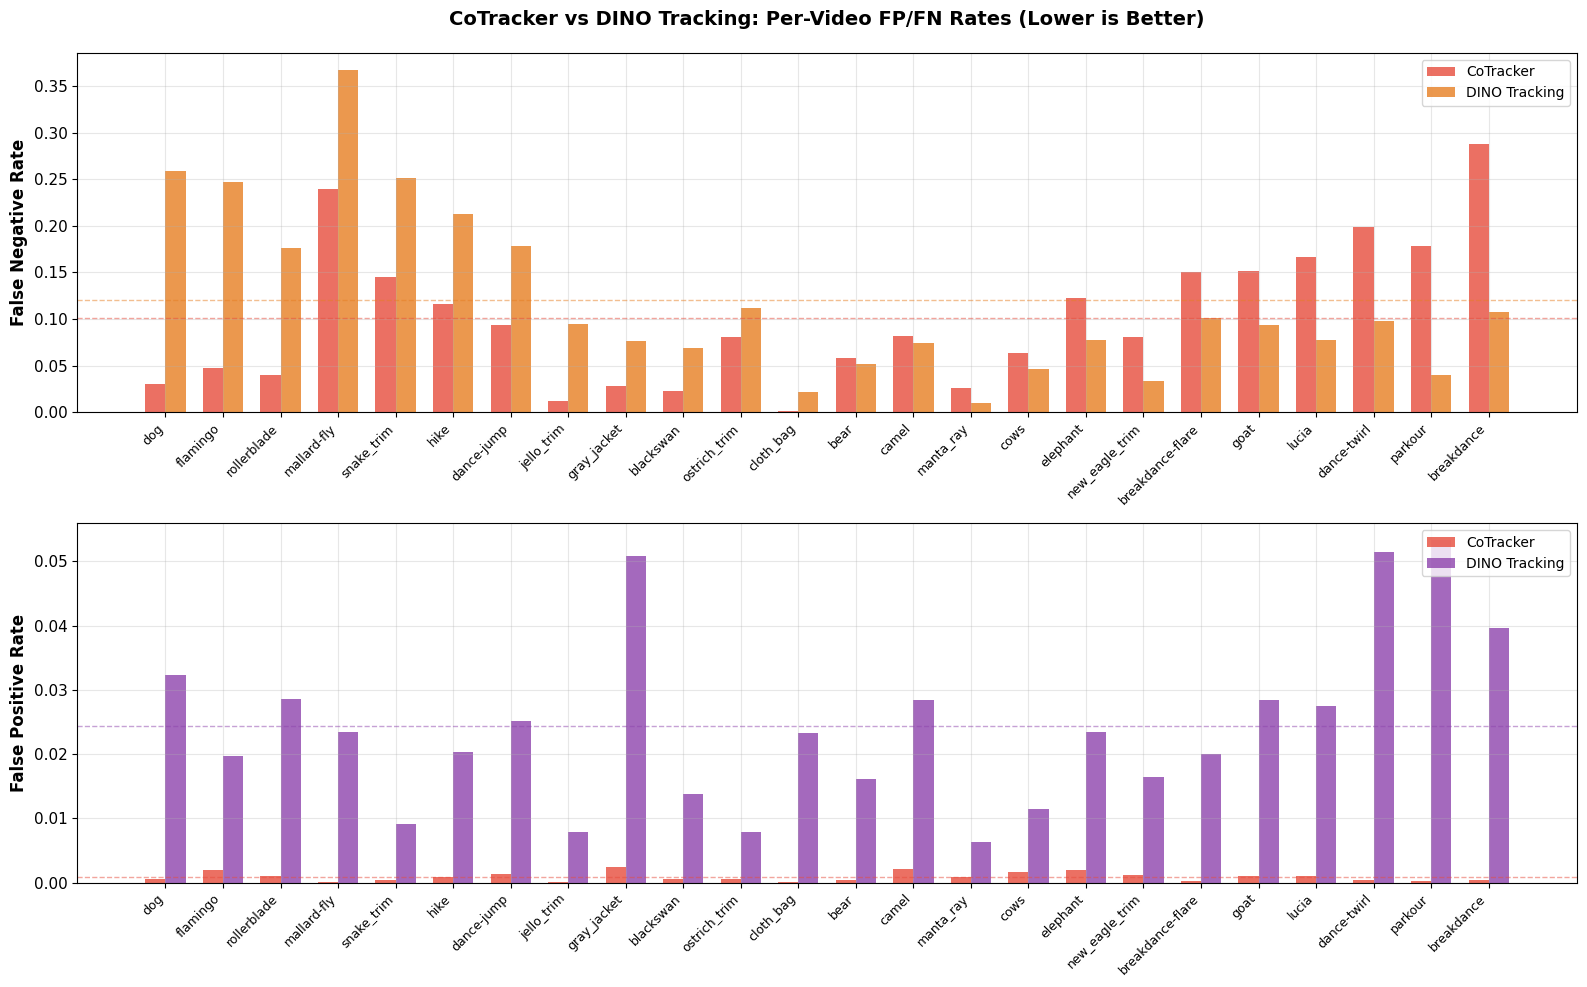

Saved: comparison_per_video_fpfn.png


In [15]:
# Sort by FN rate delta for better visualization
df_sorted_fpfn = df.sort_values('delta_fn_rate', ascending=False)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

metrics_fpfn = ['fn_rate', 'fp_rate']
metric_names_fpfn = ['False Negative Rate', 'False Positive Rate']
colors_fpfn = ['#e67e22', '#8e44ad']

for idx, (metric, name, color) in enumerate(zip(metrics_fpfn, metric_names_fpfn, colors_fpfn)):
    ax = axes[idx]
    
    x = np.arange(len(df_sorted_fpfn))
    width = 0.35
    
    ct_vals = df_sorted_fpfn[f'ct_{metric}'].values
    dino_vals = df_sorted_fpfn[f'dino_{metric}'].values
    
    ax.bar(x - width/2, ct_vals, width, label='CoTracker', alpha=0.8, color='#e74c3c')
    ax.bar(x + width/2, dino_vals, width, label='DINO Tracking', alpha=0.8, color=color)
    
    ax.set_ylabel(name, fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(df_sorted_fpfn['video'].values, rotation=45, ha='right', fontsize=9)
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.axhline(y=df[f'ct_{metric}'].mean(), color='#e74c3c', linestyle='--', 
               linewidth=1, alpha=0.5, label=f'CT Mean: {df[f"ct_{metric}"].mean():.4f}')
    ax.axhline(y=df[f'dino_{metric}'].mean(), color=color, linestyle='--', 
               linewidth=1, alpha=0.5, label=f'DINO Mean: {df[f"dino_{metric}"].mean():.4f}')

axes[0].set_title('CoTracker vs DINO Tracking: Per-Video FP/FN Rates (Lower is Better)', 
                  fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('/home/esli/GenParticles_NeurIPS/comparison_per_video_fpfn.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print("Saved: comparison_per_video_fpfn.png")


### 15. FP/FN Delta (Change) Visualization


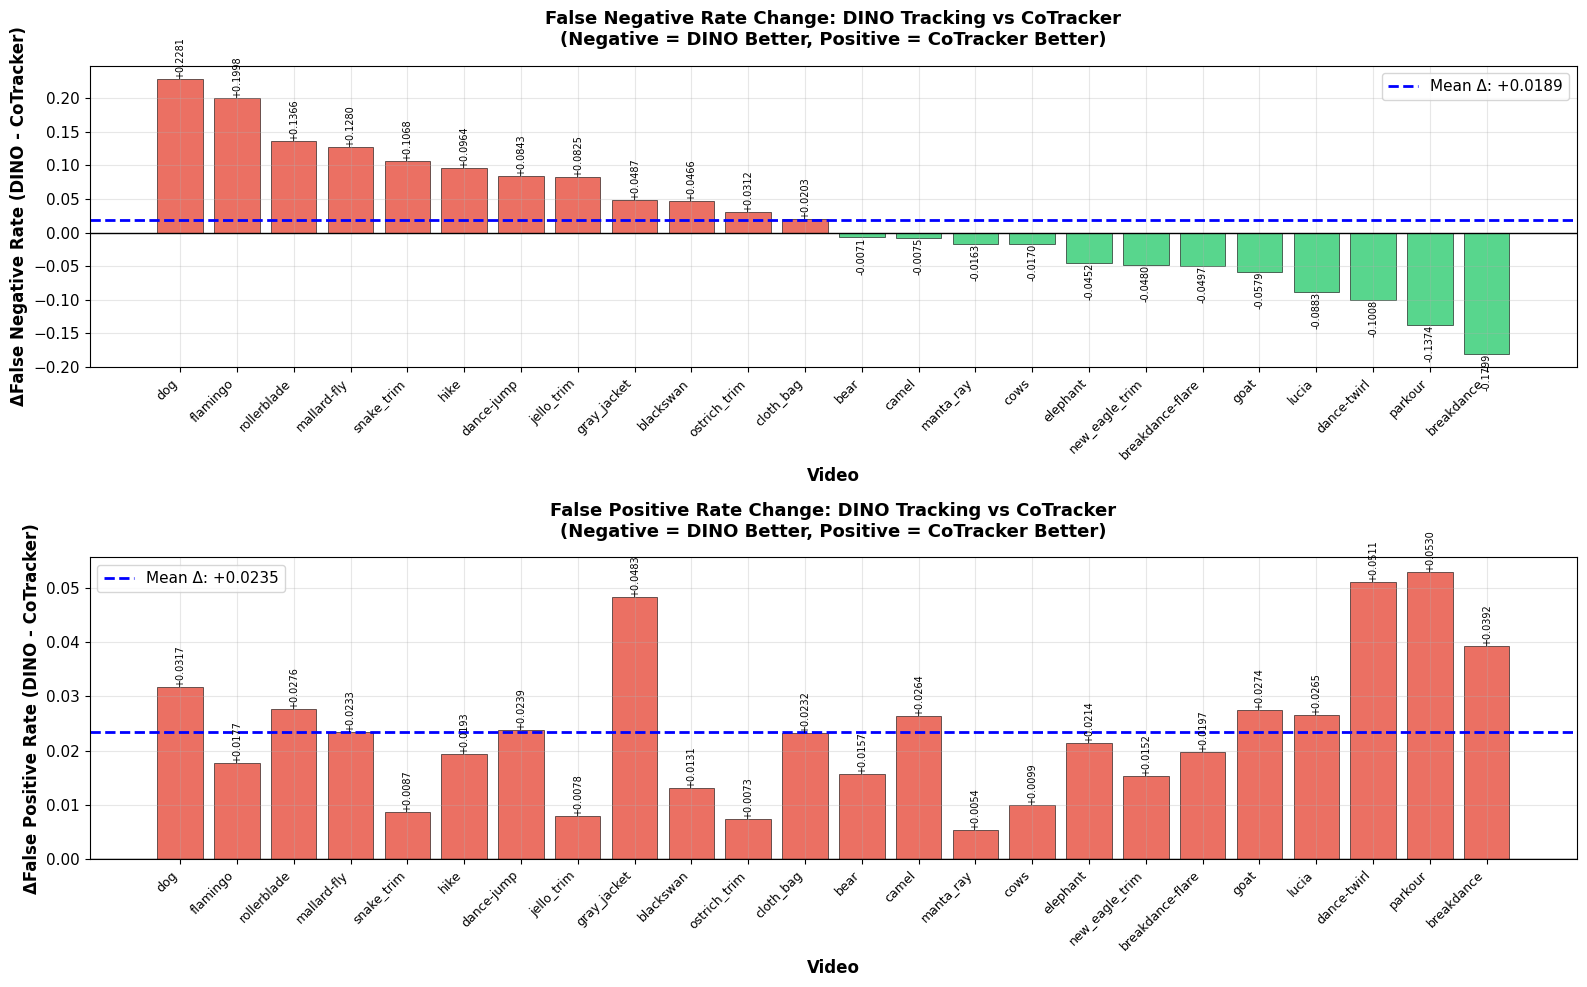

Saved: comparison_fpfn_delta.png


In [16]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

for idx, (metric, name, color) in enumerate(zip(['fn_rate', 'fp_rate'], 
                                                  ['False Negative Rate', 'False Positive Rate'],
                                                  ['#e67e22', '#8e44ad'])):
    ax = axes[idx]
    
    x = np.arange(len(df_sorted_fpfn))
    deltas = df_sorted_fpfn[f'delta_{metric}'].values
    
    # Color bars: red = DINO worse (higher errors), green = DINO better (lower errors)
    colors_bar = ['#2ecc71' if d < 0 else '#e74c3c' for d in deltas]
    
    bars = ax.bar(x, deltas, color=colors_bar, alpha=0.8, edgecolor='black', linewidth=0.5)
    
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
    ax.axhline(y=df[f'delta_{metric}'].mean(), color='blue', linestyle='--', 
               linewidth=2, label=f'Mean Δ: {df[f"delta_{metric}"].mean():+.4f}')
    
    ax.set_ylabel(f'Δ{name} (DINO - CoTracker)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Video', fontsize=12, fontweight='bold')
    ax.set_title(f'{name} Change: DINO Tracking vs CoTracker\n(Negative = DINO Better, Positive = CoTracker Better)', 
                 fontsize=13, fontweight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(df_sorted_fpfn['video'].values, rotation=45, ha='right', fontsize=9)
    ax.legend(fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for i, (bar, delta) in enumerate(zip(bars, deltas)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{delta:+.4f}',
                ha='center', va='bottom' if height > 0 else 'top', 
                fontsize=7, rotation=90)

plt.tight_layout()
plt.savefig('/home/esli/GenParticles_NeurIPS/comparison_fpfn_delta.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print("Saved: comparison_fpfn_delta.png")


### 16. FP/FN Scatter Plots: Direct Comparison


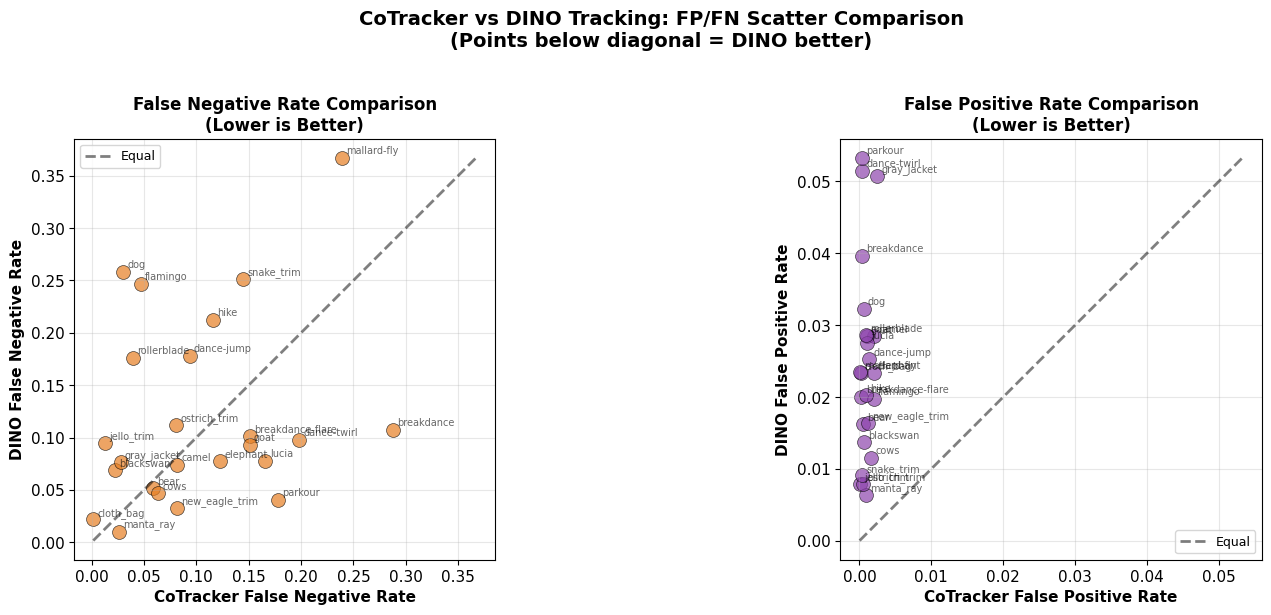

Saved: comparison_fpfn_scatter.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

metrics_fpfn = ['fn_rate', 'fp_rate']
metric_names_fpfn = ['False Negative Rate', 'False Positive Rate']
colors_fpfn = ['#e67e22', '#8e44ad']

for idx, (metric, name, color) in enumerate(zip(metrics_fpfn, metric_names_fpfn, colors_fpfn)):
    ax = axes[idx]
    
    ct_vals = df[f'ct_{metric}'].values
    dino_vals = df[f'dino_{metric}'].values
    
    ax.scatter(ct_vals, dino_vals, alpha=0.7, s=100, color=color, edgecolor='black', linewidth=0.5)
    
    # Add video labels
    for i, video in enumerate(df['video'].values):
        ax.annotate(video, (ct_vals[i], dino_vals[i]), 
                   fontsize=7, alpha=0.6, xytext=(3, 3), textcoords='offset points')
    
    # Diagonal line (equal performance)
    min_val = min(ct_vals.min(), dino_vals.min())
    max_val = max(ct_vals.max(), dino_vals.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, alpha=0.5, label='Equal')
    
    ax.set_xlabel(f'CoTracker {name}', fontsize=11, fontweight='bold')
    ax.set_ylabel(f'DINO {name}', fontsize=11, fontweight='bold')
    ax.set_title(f'{name} Comparison\n(Lower is Better)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_aspect('equal', adjustable='box')

plt.suptitle('CoTracker vs DINO Tracking: FP/FN Scatter Comparison\n(Points below diagonal = DINO better)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/home/esli/GenParticles_NeurIPS/comparison_fpfn_scatter.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print("Saved: comparison_fpfn_scatter.png")


### 17. FP/FN Statistical Significance Testing


In [18]:
from scipy import stats

print("="*100)
print("FP/FN STATISTICAL SIGNIFICANCE TESTS (Paired t-test)")
print("="*100)

for metric, name in zip(['fn_rate', 'fp_rate'], ['False Negative Rate', 'False Positive Rate']):
    ct_vals = df[f'ct_{metric}'].values
    dino_vals = df[f'dino_{metric}'].values
    
    # Paired t-test
    t_stat, p_value = stats.ttest_rel(dino_vals, ct_vals)
    
    # Effect size (Cohen's d)
    diff = dino_vals - ct_vals
    cohens_d = diff.mean() / diff.std() if diff.std() > 0 else 0
    
    print(f"\n{name}:")
    print(f"  Mean difference (DINO - CoTracker): {diff.mean():+.4f}")
    print(f"  t-statistic: {t_stat:.4f}")
    print(f"  p-value: {p_value:.4f}")
    print(f"  Cohen's d (effect size): {cohens_d:.4f}")
    
    if p_value < 0.001:
        print(f"  ✅ HIGHLY SIGNIFICANT (p < 0.001)")
    elif p_value < 0.01:
        print(f"  ✅ VERY SIGNIFICANT (p < 0.01)")
    elif p_value < 0.05:
        print(f"  ✅ SIGNIFICANT (p < 0.05)")
    else:
        print(f"  ⚠️  NOT SIGNIFICANT (p >= 0.05)")
    
    if abs(cohens_d) >= 0.8:
        print(f"  Effect size: LARGE")
    elif abs(cohens_d) >= 0.5:
        print(f"  Effect size: MEDIUM")
    elif abs(cohens_d) >= 0.2:
        print(f"  Effect size: SMALL")
    else:
        print(f"  Effect size: NEGLIGIBLE")
    
    # Interpretation
    if diff.mean() < 0:
        print(f"  📉 DINO has SIGNIFICANTLY LOWER {name} (better)")
    elif diff.mean() > 0:
        print(f"  📈 DINO has SIGNIFICANTLY HIGHER {name} (worse)")
    else:
        print(f"  ➡️  No significant difference in {name}")


FP/FN STATISTICAL SIGNIFICANCE TESTS (Paired t-test)

False Negative Rate:
  Mean difference (DINO - CoTracker): +0.0189
  t-statistic: 0.9095
  p-value: 0.3725
  Cohen's d (effect size): 0.1896
  ⚠️  NOT SIGNIFICANT (p >= 0.05)
  Effect size: NEGLIGIBLE
  📈 DINO has SIGNIFICANTLY HIGHER False Negative Rate (worse)

False Positive Rate:
  Mean difference (DINO - CoTracker): +0.0235
  t-statistic: 8.5501
  p-value: 0.0000
  Cohen's d (effect size): 1.7828
  ✅ HIGHLY SIGNIFICANT (p < 0.001)
  Effect size: LARGE
  📈 DINO has SIGNIFICANTLY HIGHER False Positive Rate (worse)


### 18. FP/FN Best/Worst Cases Analysis


In [19]:
print("="*100)
print("TOP 5 VIDEOS WHERE DINO HAS LOWER FN RATE (Better)")
print("="*100)

top_dino_fn = df.nsmallest(5, 'delta_fn_rate')
print(top_dino_fn[['video', 'ct_fn_rate', 'dino_fn_rate', 'delta_fn_rate']].to_string(index=False))

print("\n" + "="*100)
print("TOP 5 VIDEOS WHERE COTRACKER HAS LOWER FN RATE (Better)")
print("="*100)

top_cotracker_fn = df.nlargest(5, 'delta_fn_rate')
print(top_cotracker_fn[['video', 'ct_fn_rate', 'dino_fn_rate', 'delta_fn_rate']].to_string(index=False))

print("\n" + "="*100)
print("TOP 5 VIDEOS WHERE DINO HAS LOWER FP RATE (Better)")
print("="*100)

top_dino_fp = df.nsmallest(5, 'delta_fp_rate')
print(top_dino_fp[['video', 'ct_fp_rate', 'dino_fp_rate', 'delta_fp_rate']].to_string(index=False))

print("\n" + "="*100)
print("TOP 5 VIDEOS WHERE COTRACKER HAS LOWER FP RATE (Better)")
print("="*100)

top_cotracker_fp = df.nlargest(5, 'delta_fp_rate')
print(top_cotracker_fp[['video', 'ct_fp_rate', 'dino_fp_rate', 'delta_fp_rate']].to_string(index=False))

print("\n" + "="*100)
print("VIDEOS WITH VERY LOW ERROR RATES (FN < 0.05 or FP < 0.05) - EITHER METHOD")
print("="*100)

low_errors = df[(df['ct_fn_rate'] < 0.05) | (df['dino_fn_rate'] < 0.05) | 
                (df['ct_fp_rate'] < 0.05) | (df['dino_fp_rate'] < 0.05)]
if len(low_errors) > 0:
    print(low_errors[['video', 'ct_fn_rate', 'dino_fn_rate', 'ct_fp_rate', 'dino_fp_rate']].to_string(index=False))
else:
    print("No videos with very low error rates")

print("\n" + "="*100)
print("CHALLENGING VIDEOS (High Error Rates: FN > 0.10 or FP > 0.10) - EITHER METHOD")
print("="*100)

high_errors = df[(df['ct_fn_rate'] > 0.10) | (df['dino_fn_rate'] > 0.10) | 
                 (df['ct_fp_rate'] > 0.10) | (df['dino_fp_rate'] > 0.10)]
if len(high_errors) > 0:
    print(high_errors[['video', 'ct_fn_rate', 'dino_fn_rate', 'ct_fp_rate', 'dino_fp_rate']].to_string(index=False))
else:
    print("No videos with very high error rates")


TOP 5 VIDEOS WHERE DINO HAS LOWER FN RATE (Better)
      video  ct_fn_rate  dino_fn_rate  delta_fn_rate
 breakdance    0.287619      0.107681      -0.179938
    parkour    0.177778      0.040404      -0.137374
dance-twirl    0.198373      0.097612      -0.100760
      lucia    0.166063      0.077734      -0.088329
       goat    0.150965      0.093098      -0.057867

TOP 5 VIDEOS WHERE COTRACKER HAS LOWER FN RATE (Better)
      video  ct_fn_rate  dino_fn_rate  delta_fn_rate
        dog    0.030132      0.258225       0.228093
   flamingo    0.047016      0.246835       0.199819
rollerblade    0.039916      0.176471       0.136555
mallard-fly    0.239130      0.367150       0.128019
 snake_trim    0.144585      0.251423       0.106838

TOP 5 VIDEOS WHERE DINO HAS LOWER FP RATE (Better)
       video  ct_fp_rate  dino_fp_rate  delta_fp_rate
   manta_ray    0.000902      0.006305       0.005403
ostrich_trim    0.000550      0.007869       0.007319
  jello_trim    0.000025      0.007875    

### 19. FP/FN Box Plot Comparison


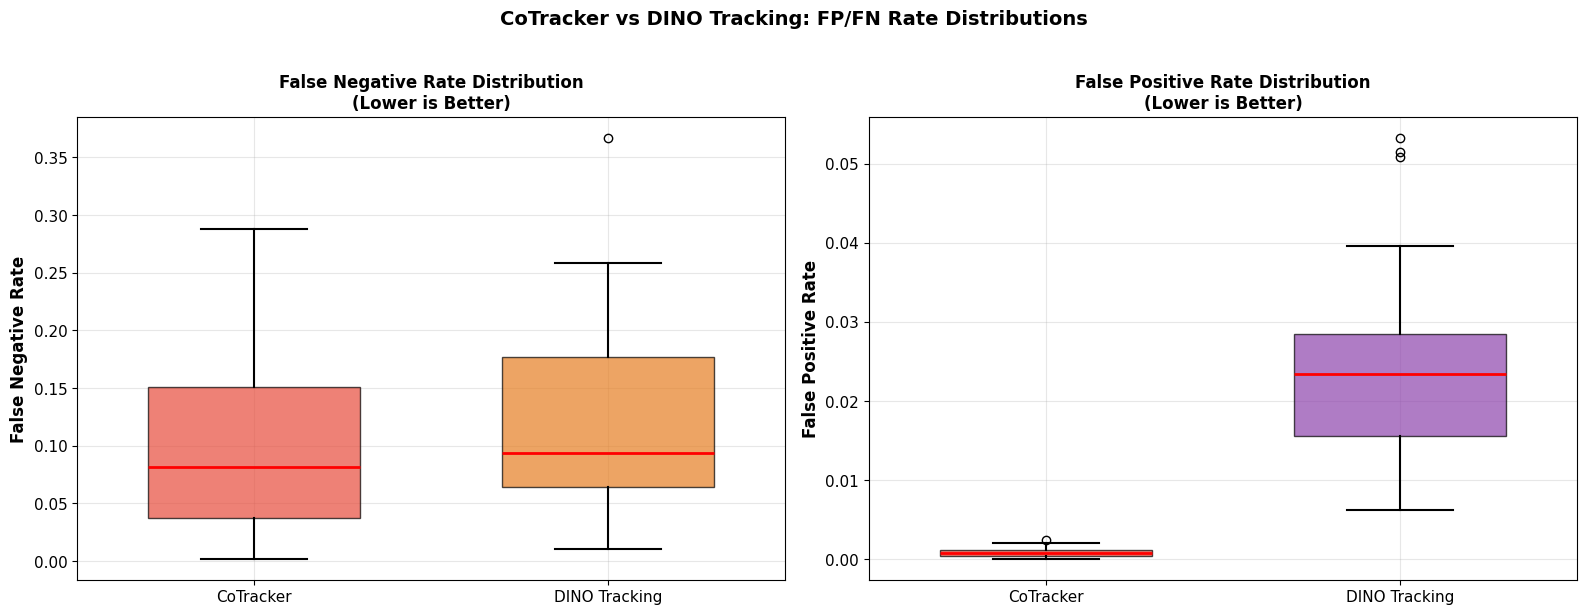

Saved: comparison_fpfn_boxplot.png


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

metrics_fpfn = ['fn_rate', 'fp_rate']
metric_names_fpfn = ['False Negative Rate', 'False Positive Rate']
colors_fpfn = ['#e67e22', '#8e44ad']

for idx, (metric, name, color) in enumerate(zip(metrics_fpfn, metric_names_fpfn, colors_fpfn)):
    ax = axes[idx]
    
    data_to_plot = [
        df[f'ct_{metric}'].values,
        df[f'dino_{metric}'].values
    ]
    
    bp = ax.boxplot(data_to_plot, tick_labels=['CoTracker', 'DINO Tracking'],
                     patch_artist=True, widths=0.6,
                     boxprops=dict(facecolor='lightgray', alpha=0.7),
                     medianprops=dict(color='red', linewidth=2),
                     whiskerprops=dict(linewidth=1.5),
                     capprops=dict(linewidth=1.5))
    
    # Color the boxes
    bp['boxes'][0].set_facecolor('#e74c3c')
    bp['boxes'][1].set_facecolor(color)
    
    ax.set_ylabel(name, fontsize=12, fontweight='bold')
    ax.set_title(f'{name} Distribution\n(Lower is Better)', fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('CoTracker vs DINO Tracking: FP/FN Rate Distributions', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/home/esli/GenParticles_NeurIPS/comparison_fpfn_boxplot.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print("Saved: comparison_fpfn_boxplot.png")


### 20. FP/FN Correlation with Overall Performance


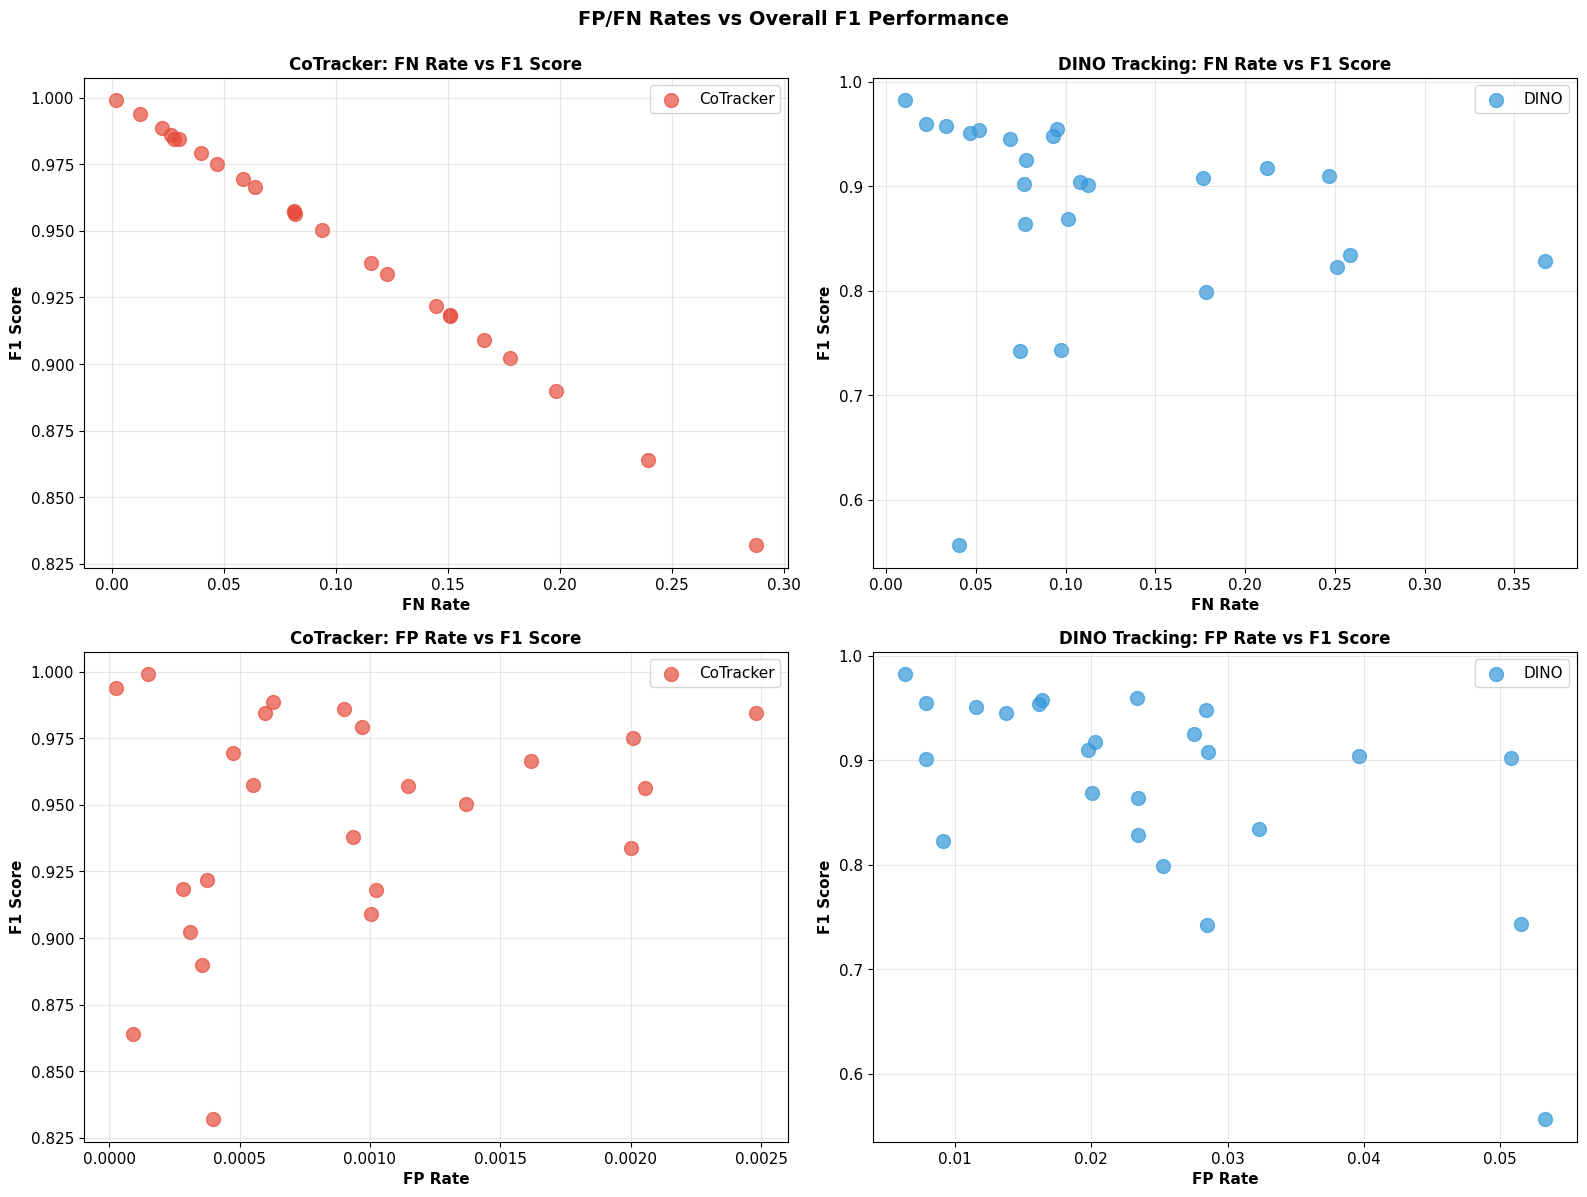

Saved: comparison_fpfn_vs_f1.png

CORRELATION ANALYSIS: FP/FN Rates vs F1 Scores

CoTracker FN vs F1:
  Correlation: -0.9990
  p-value: 0.0000
  Strength: STRONG

CoTracker FP vs F1:
  Correlation: 0.2837
  p-value: 0.1792
  Strength: WEAK

DINO FN vs F1:
  Correlation: -0.1656
  p-value: 0.4395
  Strength: NEGLIGIBLE

DINO FP vs F1:
  Correlation: -0.6105
  p-value: 0.0015
  Strength: MODERATE


In [21]:
# Analyze relationship between FP/FN rates and F1 scores
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# FN Rate vs F1 for both methods
axes[0, 0].scatter(df['ct_fn_rate'], df['ct_f1'], alpha=0.7, s=100, color='#e74c3c', label='CoTracker')
axes[0, 0].set_xlabel('FN Rate', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('F1 Score', fontsize=11, fontweight='bold')
axes[0, 0].set_title('CoTracker: FN Rate vs F1 Score', fontsize=12, fontweight='bold')
axes[0, 0].grid(alpha=0.3)
axes[0, 0].legend()

axes[0, 1].scatter(df['dino_fn_rate'], df['dino_f1'], alpha=0.7, s=100, color='#3498db', label='DINO')
axes[0, 1].set_xlabel('FN Rate', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('F1 Score', fontsize=11, fontweight='bold')
axes[0, 1].set_title('DINO Tracking: FN Rate vs F1 Score', fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3)
axes[0, 1].legend()

# FP Rate vs F1 for both methods
axes[1, 0].scatter(df['ct_fp_rate'], df['ct_f1'], alpha=0.7, s=100, color='#e74c3c', label='CoTracker')
axes[1, 0].set_xlabel('FP Rate', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('F1 Score', fontsize=11, fontweight='bold')
axes[1, 0].set_title('CoTracker: FP Rate vs F1 Score', fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3)
axes[1, 0].legend()

axes[1, 1].scatter(df['dino_fp_rate'], df['dino_f1'], alpha=0.7, s=100, color='#3498db', label='DINO')
axes[1, 1].set_xlabel('FP Rate', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('F1 Score', fontsize=11, fontweight='bold')
axes[1, 1].set_title('DINO Tracking: FP Rate vs F1 Score', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3)
axes[1, 1].legend()

plt.suptitle('FP/FN Rates vs Overall F1 Performance', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('/home/esli/GenParticles_NeurIPS/comparison_fpfn_vs_f1.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print("Saved: comparison_fpfn_vs_f1.png")

# Compute correlations
from scipy.stats import pearsonr

print("\n" + "="*100)
print("CORRELATION ANALYSIS: FP/FN Rates vs F1 Scores")
print("="*100)

correlations = {
    'CoTracker FN vs F1': pearsonr(df['ct_fn_rate'], df['ct_f1']),
    'CoTracker FP vs F1': pearsonr(df['ct_fp_rate'], df['ct_f1']),
    'DINO FN vs F1': pearsonr(df['dino_fn_rate'], df['dino_f1']),
    'DINO FP vs F1': pearsonr(df['dino_fp_rate'], df['dino_f1']),
}

for name, (corr, pval) in correlations.items():
    print(f"\n{name}:")
    print(f"  Correlation: {corr:.4f}")
    print(f"  p-value: {pval:.4f}")
    if abs(corr) > 0.7:
        strength = "STRONG"
    elif abs(corr) > 0.4:
        strength = "MODERATE"
    elif abs(corr) > 0.2:
        strength = "WEAK"
    else:
        strength = "NEGLIGIBLE"
    print(f"  Strength: {strength}")


In [22]:
## Final Summary: Net Accuracy by Dataset

print("="*100)
print("FINAL SUMMARY: NET ACCURACY BY DATASET")
print("="*100)
print("Accuracy = (TP + TN) / Total = (Correct Particles) / (Total Particles)")
print("="*100)

# Create accuracy table for each video
accuracy_table = df[['video',
                     'ct_accuracy', 'dino_accuracy', 'delta_accuracy']].copy()

# Sort by accuracy delta for better readability
accuracy_table = accuracy_table.sort_values('delta_accuracy', ascending=False)

print("\n📊 Accuracy by Dataset (Video):")
print("="*100)

# Format the table
display_df = accuracy_table.copy()

# Format as percentages
display_df['ct_accuracy'] = display_df['ct_accuracy'].apply(lambda x: f"{x*100:.2f}%")
display_df['dino_accuracy'] = display_df['dino_accuracy'].apply(lambda x: f"{x*100:.2f}%")
display_df['delta_accuracy'] = display_df['delta_accuracy'].apply(lambda x: f"{x*100:+.2f}%")

# Rename columns
display_df.columns = ['Video', 'CoTracker Accuracy', 'DINO Accuracy', 'Δ Accuracy']

print(display_df.to_string(index=False))

print("\n" + "="*100)
print("AGGREGATE NET ACCURACY")
print("="*100)

print(f"\n{'Method':<20} {'Accuracy':<15} {'Accuracy %':<15}")
print("-" * 50)
ct_acc_mean = df['ct_accuracy'].mean()
dino_acc_mean = df['dino_accuracy'].mean()
delta_acc_mean = df['delta_accuracy'].mean()
print(f"{'CoTracker':<20} {ct_acc_mean:<15.4f} {ct_acc_mean*100:<15.2f}%")
print(f"{'DINO Tracking':<20} {dino_acc_mean:<15.4f} {dino_acc_mean*100:<15.2f}%")
print(f"{'Δ (DINO-CT)':<20} {delta_acc_mean:<15.4f} {delta_acc_mean*100:<15.2f}%")

print("\n" + "="*100)
print("WIN/LOSS SUMMARY")
print("="*100)
dino_wins = (df['delta_accuracy'] > 0).sum()
ct_wins = (df['delta_accuracy'] < 0).sum()
ties = (df['delta_accuracy'] == 0).sum()

print(f"\nAccuracy (higher is better):")
print(f"  DINO better:     {dino_wins:2d} / {len(df)} ({100*dino_wins/len(df):.1f}%)")
print(f"  CoTracker better: {ct_wins:2d} / {len(df)} ({100*ct_wins/len(df):.1f}%)")
print(f"  Tied:           {ties:2d} / {len(df)} ({100*ties/len(df):.1f}%)")

print("\n" + "="*100)
print("OVERALL WINNER")
print("="*100)
if delta_acc_mean > 0.01:
    print(f"✅ DINO Tracking wins with {delta_acc_mean*100:+.2f}% higher accuracy")
elif delta_acc_mean < -0.01:
    print(f"✅ CoTracker wins with {abs(delta_acc_mean)*100:.2f}% higher accuracy")
else:
    print("⚖️  Methods are comparable (difference < 1%)")
print("="*100)


FINAL SUMMARY: NET ACCURACY BY DATASET
Accuracy = (TP + TN) / Total = (Correct Particles) / (Total Particles)

📊 Accuracy by Dataset (Video):
           Video CoTracker Accuracy DINO Accuracy Δ Accuracy
       manta_ray             99.55%        99.34%     -0.21%
            cows             98.99%        98.34%     -0.65%
    ostrich_trim             99.53%        98.75%     -0.78%
  new_eagle_trim             99.07%        98.25%     -0.82%
      snake_trim             99.15%        98.10%     -1.05%
        elephant             97.96%        96.85%     -1.11%
breakdance-flare             98.68%        97.45%     -1.22%
            bear             99.29%        98.01%     -1.28%
      jello_trim             99.84%        98.36%     -1.48%
       blackswan             99.75%        98.19%     -1.55%
      breakdance             97.26%        95.48%     -1.78%
            goat             98.73%        96.78%     -1.94%
            hike             99.31%        97.34%     -1.97%
    